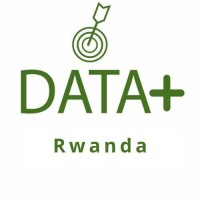
# Final Project
---
# Name : IBYIMANIKORA Benitha
---
Attempt the following questions using the 2023 Labor Force Data and identify variables to use from the variable description file.

Write a short narrative for each summary or plot.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
path =r"C:\Users\user\OneDrive\Documents\PYTHON For DS\Data\RW_LFS2023.csv"
RLF2023 = pd.read_csv(path,encoding = 'unicode_escape')
RLF2023.rename(columns={'D07':'contract_type','act_hrs':'hours_worked','A05':'marital_status', 'IEV2':'job_type','Code_UR':'location',
                        'LFS_year':'year', 'UD':'unemployment_duration', 'hhsize':'house_hold_size', 'E11':'dual_jobs',
                        'main_sect':'sector','attained':'Education_level','status1':'employement_status','province':'region',
                        'code_dis':'District','A01':'Gender','A04':'Age','indb05':'Edu_field','indd03':'Business',
                        'isco2digit':'Occupation','cash':'Mthly_inc'}, inplace= True)
RLF2023_sub = RLF2023[['D10A','region','contract_type','sector','disable','Education_level','year','HHID','employement_status',
                       'unemployment_duration','house_hold_size','hours_worked','dual_jobs','District','marital_status','job_type','Gender','Age','location','Edu_field', 'Business', 'Occupation', 'Mthly_inc']]

C:\Users\user\AppData\Local\Temp\ipykernel_15388\299490383.py:2: DtypeWarning: Columns (58,113,212) have mixed types. Specify dtype option on import or set low_memory=False.
  RLF2023 = pd.read_csv(path,encoding = 'unicode_escape')


##### Question 1. What is the employment rate by gender?

C:\Users\user\AppData\Local\Temp\ipykernel_33396\4225708209.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  RLF2023_sub['Gender'].fillna(RLF2023_sub['Gender'].mode()[0], inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_33396\4225708209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RLF2023_sub['Gender'].fillna(RLF2023_sub['Gen

   Gender  Employment Rate (%)
0  Female            79.666693
1    Male            86.204951


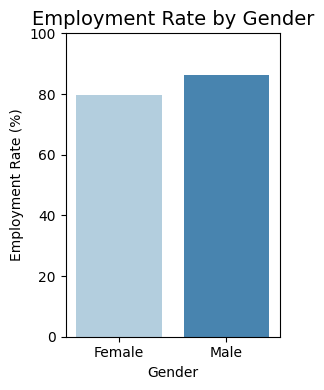

In [ ]:
RLF2023_sub['Gender'].fillna(RLF2023_sub['Gender'].mode()[0], inplace=True)

table = pd.crosstab(RLF2023_sub['Gender'], RLF2023_sub['employement_status'])
employment_rate = (table['Employed'] / (table['Employed'] + table['Unemployed'])).reset_index()
employment_rate.columns = ['Gender', 'Employment Rate (%)']
employment_rate['Employment Rate (%)'] = employment_rate['Employment Rate (%)'] * 100
print(employment_rate)

plt.figure(figsize=(3, 4))
sns.barplot(data=employment_rate, x='Gender', y='Employment Rate (%)', palette='Blues')
plt.title("Employment Rate by Gender", fontsize=14)
plt.ylabel("Employment Rate (%)")
plt.xlabel("Gender")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

##### The employment rate by gender shows that males have a higher employment rate compared to females. This indicates persistent gender disparities in labor force participation, which may be influenced by factors such as cultural norms, caregiving responsibilities, and differences in access to education or formal job opportunities. Addressing these disparities is important for promoting gender equality and economic development.

#### Question 2:What is the unemployment rate by region?

              region  Unemployment Rate (%)
0   Eastern Province              16.014576
1        Kigali city              16.801060
2  Northern Province              17.640604
3  Southern Province              16.222374
4   Western Province              17.990496


C:\Users\user\AppData\Local\Temp\ipykernel_33396\3314611628.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=Unemployment_rate_by_region,x='region',y='Unemployment Rate (%)',palette='Blues')


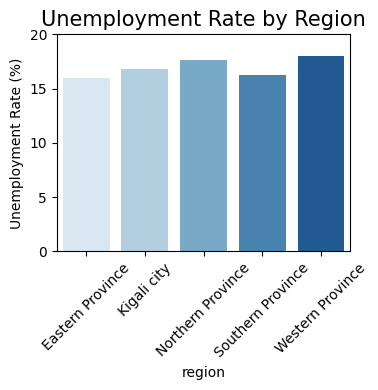

In [ ]:
region_tot= pd.crosstab(RLF2023_sub['region'], RLF2023_sub['employement_status'])
Unemployment_rate_by_region = (region_tot['Unemployed'] / (region_tot['Unemployed'] + region_tot['Employed'])).reset_index()
Unemployment_rate_by_region.columns = ['region', 'Unemployment Rate (%)']
Unemployment_rate_by_region['Unemployment Rate (%)'] *= 100
print(Unemployment_rate_by_region)

plt.figure(figsize=(4, 4))
sns.barplot( data=Unemployment_rate_by_region,x='region',y='Unemployment Rate (%)',palette='Blues')
plt.title('Unemployment Rate by Region', fontsize=15)
plt.xlabel('region')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

- **Unemployment Rate by Region:** Western Province and Kigali city show the highest unemployment rates, likely due to urban migration and job competition.


##### The unemployment rate by region reveals significant regional disparities. Kigali city and Western Province have the highest unemployment rates, which may be attributed to urban migration, increased job competition, and the concentration of job seekers in urban centers. In contrast, Eastern, Northern, and Southern Provinces show lower unemployment rates, likely due to the prevalence of agricultural and informal employment, where many individuals are engaged in subsistence activities not always classified as unemployed. These trends highlight the impact of urbanization, economic structure, and labor market dynamics on unemployment, suggesting that targeted regional policies are needed to address job creation and reduce unemployment in high-risk areas.

#### Question 3:What is the average income by education level?

   Education Level  Average Monthly Income
0  Lower secondary            81384.879120
1          Primary            52121.829834
2       University           360313.261571
3  Upper secondary           116905.138864


C:\Users\user\AppData\Local\Temp\ipykernel_33396\1168442114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Education Level', y='Average Monthly Income', data=avg_income_edu, palette='viridis')


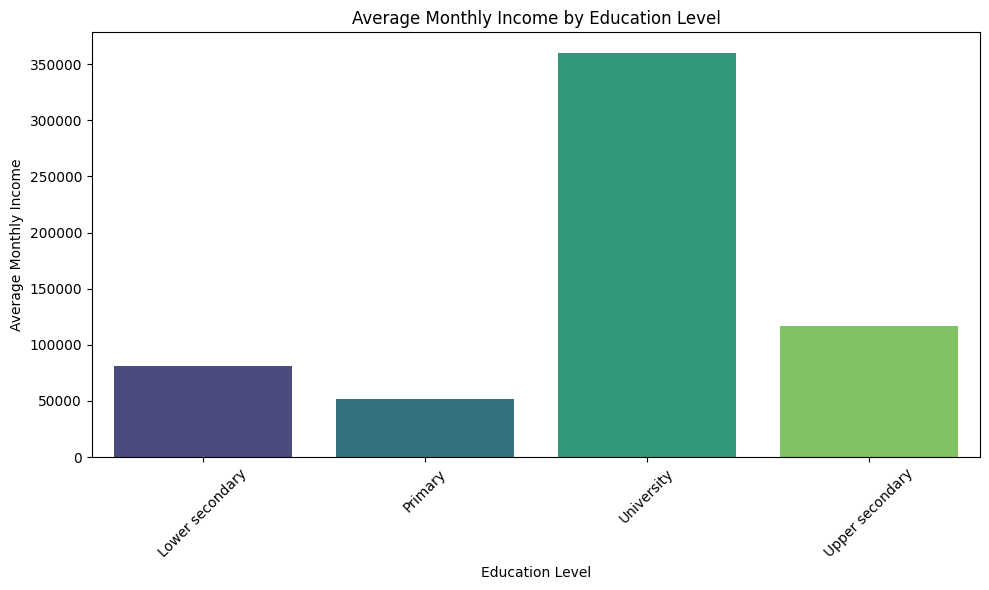

In [ ]:

df_income_edu = RLF2023_sub.dropna(subset=['Mthly_inc', 'Education_level'])

avg_income_edu = df_income_edu.groupby('Education_level')['Mthly_inc'].mean().reset_index()
avg_income_edu.columns = ['Education Level', 'Average Monthly Income']
print(avg_income_edu)

plt.figure(figsize=(10, 6))
sns.barplot(x='Education Level', y='Average Monthly Income', data=avg_income_edu, palette='viridis')
plt.title('Average Monthly Income by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- **Income by Education Level:** Higher education levels (University, Upper secondary) are associated with higher average monthly incomes, highlighting the economic value of education.

##### The analysis of average income by education level shows a clear upward trend: individuals with higher education (such as University and Upper secondary) earn significantly more on average than those with only Primary or Lower secondary education. This pattern highlights the economic value of investing in education, as advanced qualifications open access to better-paying jobs and career opportunities. However, the gap also reflects structural inequalities—those with less education are often limited to lower-wage, informal, or manual jobs. Promoting access to quality education and skills development is essential for improving income levels and reducing economic disparities.

#### Question 4: What is the labor force participation by age group?

C:\Users\user\AppData\Local\Temp\ipykernel_27808\811125737.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RLF2023_sub['Age_Group'] = pd.cut(RLF2023_sub['Age'], bins=bins, labels=labels, right=False)
C:\Users\user\AppData\Local\Temp\ipykernel_27808\811125737.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  participation_rate = labor_force.groupby('Age_Group').size() / RLF2023_sub.groupby('Age_Group').size() * 100
C:\Users\user\AppData\Local\Temp\ipykernel_27808\811125737.py:10: FutureWarning: The default of observed=False is deprecated and will be ch

  Age Group  Labor Force Participation Rate (%)
0      0-14                            0.000000
1     15-24                           27.606101
2     25-34                           63.495769
3     35-44                           66.845652
4     45-54                           60.860340
5     55-64                           42.961449
6       65+                           16.944960


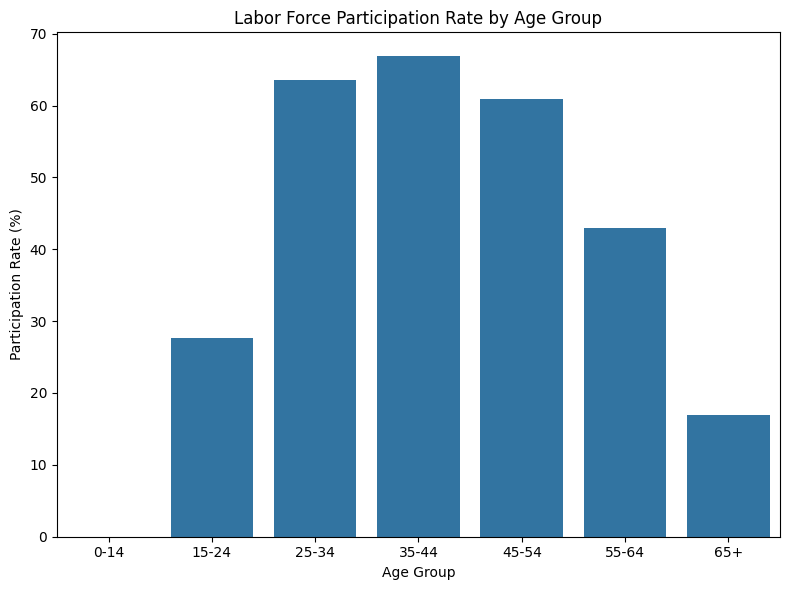

In [ ]:

bins = [0, 14, 24, 34, 44, 54, 64, 100]
labels = ['0-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65+']
RLF2023_sub['Age_Group'] = pd.cut(RLF2023_sub['Age'], bins=bins, labels=labels, right=False)

labor_force = RLF2023_sub[RLF2023_sub['Occupation'].notna()]


participation_rate = labor_force.groupby('Age_Group').size() / RLF2023_sub.groupby('Age_Group').size() * 100
participation_rate = participation_rate.reset_index()
participation_rate.columns = ['Age Group', 'Labor Force Participation Rate (%)']
print(participation_rate)

plt.figure(figsize=(8, 6))
sns.barplot(x='Age Group', y='Labor Force Participation Rate (%)', data=participation_rate)
plt.title('Labor Force Participation Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Participation Rate (%)')
plt.tight_layout()
plt.show()

- **Labor Force Participation by Age Group:** Participation peaks in the 25-54 age range and drops for younger and older groups, reflecting typical working-age patterns.

##### The labor force participation rate by age group shows that participation is lowest among the youngest (0-14) and oldest (65+) age groups, as most individuals in these groups are not of working age or have retired. Participation increases sharply in the 15-24 age group as people enter the workforce, and peaks in the prime working years (25-54), reflecting the typical age range for economic activity. After age 54, participation begins to decline, likely due to retirement or withdrawal from the labor market. This trend highlights the importance of age in shaping labor force engagement, with the highest participation seen in the core working-age population.

#### Question 5: What sector employs the most people?


        Sector  Number Employed
0     Services            10588
1  Agriculture             7426
2     Industry             4200


C:\Users\user\AppData\Local\Temp\ipykernel_27808\726241470.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Sector', x='Number Employed', data=sector_counts, palette='crest')


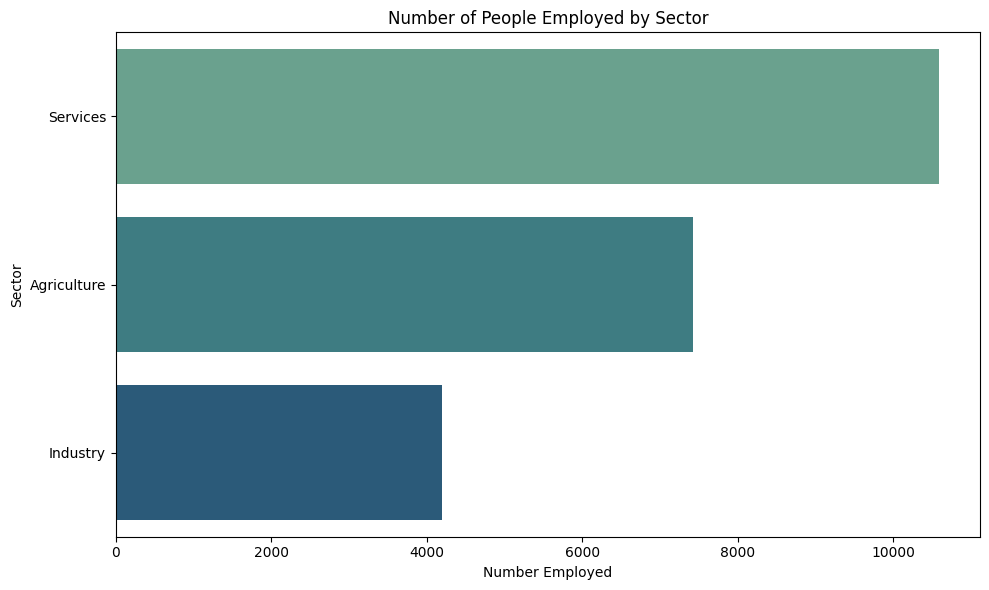

In [ ]:


sector_counts = RLF2023_sub['sector'].value_counts().reset_index()
sector_counts.columns = ['Sector', 'Number Employed']
print(sector_counts)

plt.figure(figsize=(10, 6))
sns.barplot(y='Sector', x='Number Employed', data=sector_counts, palette='crest')
plt.title('Number of People Employed by Sector')
plt.xlabel('Number Employed')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

- **Sectoral Employment:** The services sector employs the most people, followed by agriculture and industry.

##### The analysis of sectoral employment shows that the services sector employs the most people, followed by agriculture and industry. This trend reflects ongoing economic transformation, urbanization, and the expansion of service-related activities such as trade, education, health, and hospitality. While agriculture remains significant, especially in rural areas, the shift toward services indicates diversification and modernization of the labor market. The dominance of services also suggests increased opportunities in formal and informal jobs, but may highlight challenges for those with lower education or skills, who are often concentrated in agriculture. Promoting balanced growth across sectors is important for inclusive employment and sustainable development.

#### Question 6:What is the gender distribution in each sector?


Gender       Female  Male
sector                   
Agriculture    4081  3345
Industry       1018  3182
Services       4892  5696


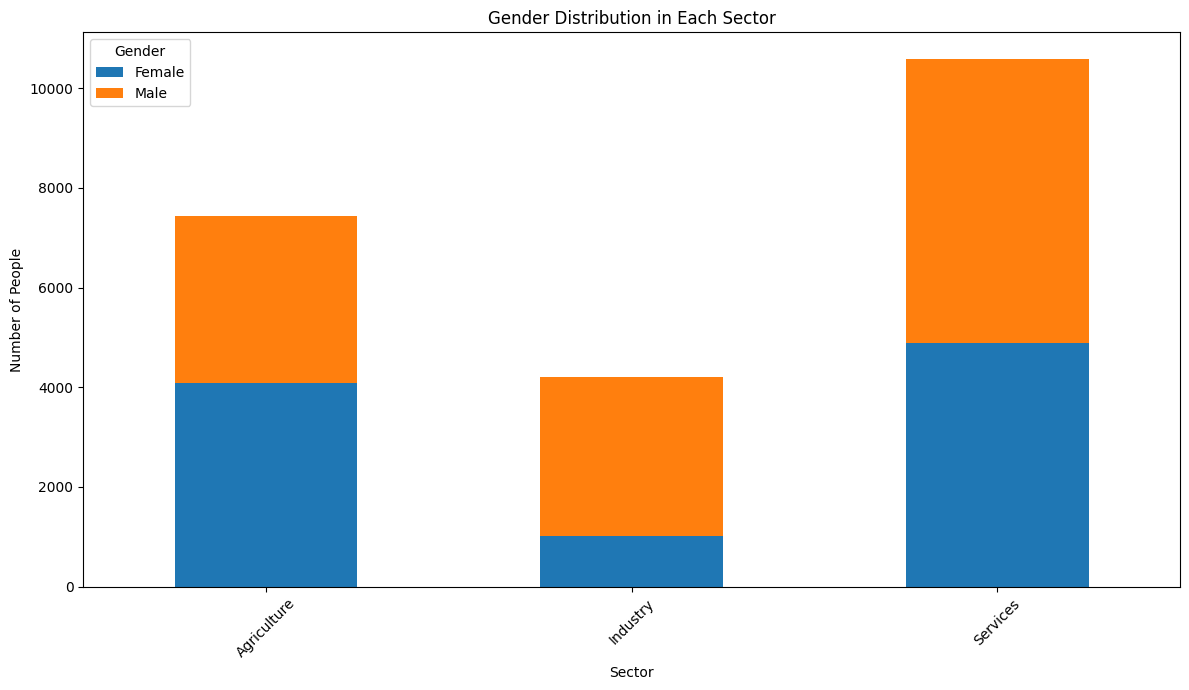

In [ ]:

gender_sector = RLF2023_sub.groupby(['sector', 'Gender']).size().reset_index(name='Count')
gender_sector_pivot = gender_sector.pivot(index='sector', columns='Gender', values='Count').fillna(0)
print(gender_sector_pivot)
gender_sector_pivot.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Gender Distribution in Each Sector')
plt.xlabel('Sector')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

- **Gender Distribution in Sectors:** Some sectors (e.g., services) have a more balanced gender distribution, while others (e.g., agriculture) are male-dominated.

##### The gender distribution in each sector reveals notable differences. In the agriculture sector, males tend to dominate, reflecting traditional roles and labor patterns. The services sector shows a more balanced gender distribution, with both males and females participating in similar numbers, likely due to diverse job opportunities and less physical labor. The industry sector is also male-dominated, possibly because of the nature of industrial jobs. These trends highlight ongoing gender disparities in employment across sectors, influenced by cultural norms, education, and access to opportunities. Promoting gender equality in all sectors is important for inclusive economic growth.

#### Question 7:What’s the mean working hours by occupation?

C:\Users\user\AppData\Local\Temp\ipykernel_27808\3757580017.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RLF2023_sub['hours_worked'] = pd.to_numeric(RLF2023_sub['hours_worked'], errors='coerce')


                                           Occupation  Average(Mean)
0                                                   5     114.000000
1              Administrative and commercial managers      45.546296
2        Agricultural, forestry and fishery labourers      22.092645
3                                          Assemblers      35.370370
4   Building and related trades workers, excluding...      29.607330
5   Business and administration associate professi...      43.200000
6           Business and administration professionals      44.666667
7   Chief executives, senior officials and legisla...      45.297872
8                                Cleaners and helpers      47.108499
9                            Customer services clerks      43.266667
10                 Drivers and mobile plant operators      47.787234
11           Electrical and electronic trades workers      31.095238
12                        Food preparation assistants      40.088889
13  Food processing, wood working,

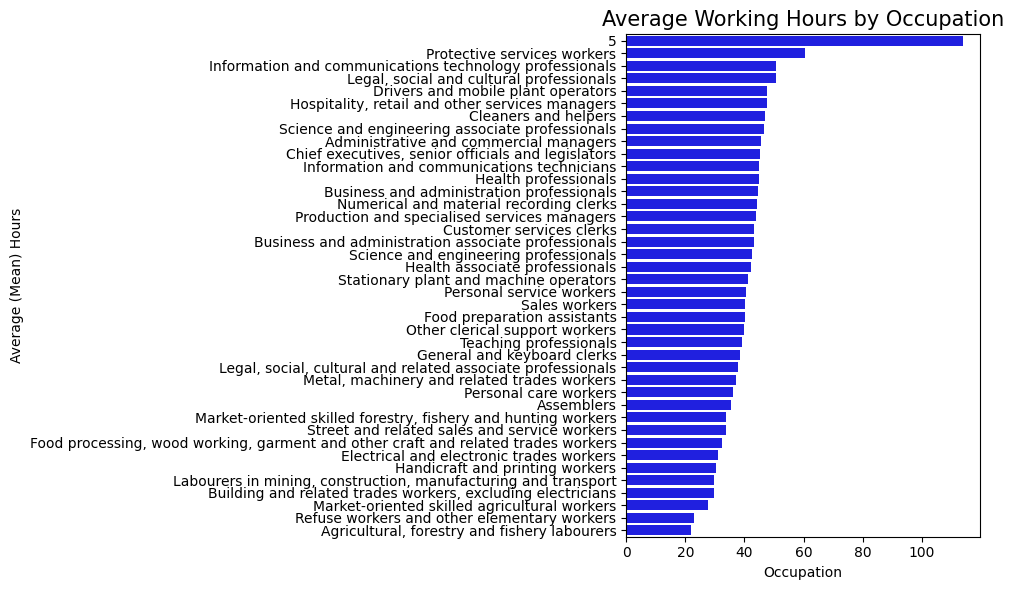

In [21]:
# Convert hours_worked to numeric and fill missing with mean
RLF2023_sub['hours_worked'] = pd.to_numeric(RLF2023_sub['hours_worked'], errors='coerce')

hours = RLF2023_sub.groupby('Occupation')['hours_worked'].mean().reset_index()
hours.columns = ['Occupation', 'Average(Mean)']
print(hours)

# Plot
plt.figure(figsize=(10, 6)) 
sns.barplot(data=hours.sort_values('Average(Mean)', ascending=False), x='Average(Mean)', y='Occupation', color='Blue')
plt.title('Average Working Hours by Occupation', fontsize=15)
plt.xlabel('Occupation')
plt.ylabel('Average (Mean) Hours')
plt.tight_layout()
plt.show()

##### The bar chart of mean working hours by occupation reveals significant variation across different job types. Occupations such as "Sales workers," "Personal service workers," and "Protective services workers" tend to have longer average working hours, often exceeding 40 hours per week, reflecting the demands of service-oriented and frontline roles. In contrast, jobs like "Cleaners and helpers" and "Agricultural, forestry and fishery labourers" generally have shorter average hours, possibly due to part-time arrangements or seasonal work. Specialized professions and managerial roles may also show moderate working hours, balancing administrative duties with fieldwork. These trends highlight how job nature, sector, and employment type influence weekly working hours, with service and sales roles typically requiring more time commitment than manual or support occupations.

#### Question 8:Income inequality by gender

   Gender   Mean Income     Std Income
0  Female  62972.490703  160629.465466
1    Male  98877.773591  231775.188527


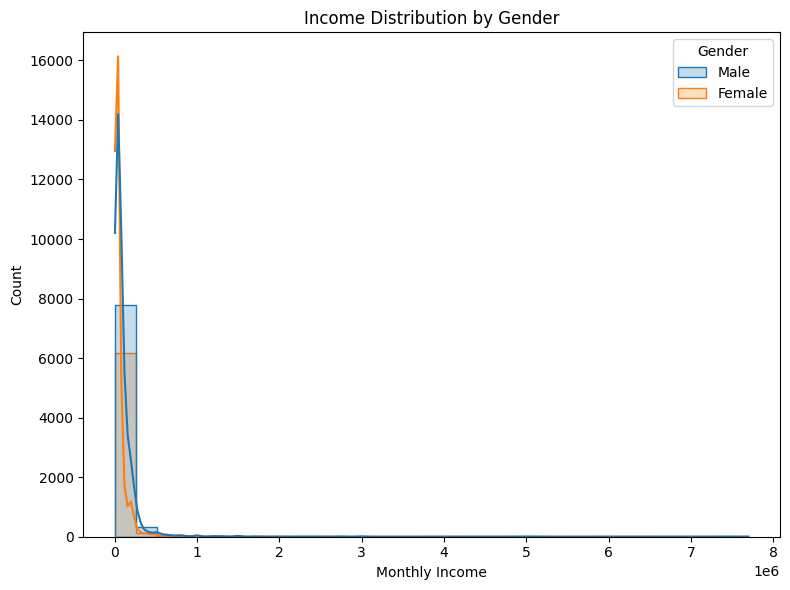

In [ ]:

income_stats = RLF2023_sub.groupby('Gender')['Mthly_inc'].agg(['mean', 'std']).reset_index()
income_stats.columns = ['Gender', 'Mean Income', 'Std Income']
print(income_stats)
plt.figure(figsize=(8, 6))
sns.histplot(data=RLF2023_sub, x='Mthly_inc', hue='Gender', bins=30, kde=True, element='step')
plt.title('Income Distribution by Gender')
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



- **Income Inequality by Gender:** Males earn higher mean incomes and have greater income variability compared to females.

##### The analysis of income inequality by gender reveals that males earn higher average monthly incomes and exhibit greater income variability compared to females. This disparity may be attributed to factors such as occupational segregation, differences in access to higher-paying jobs, and social norms that influence career choices and opportunities. The income distribution plot shows that men are more represented at higher income levels, while women are concentrated at lower ranges. Addressing gender income inequality requires targeted policies to promote equal pay, improve access to education and formal employment for women, and support career advancement opportunities across all sectors.

#### Question 9:Distribution of unemployment by education level??


   Education Level  Number Unemployed
0          Primary               1412
1  Upper secondary                686
2  Lower secondary                375
3       University                258


C:\Users\user\AppData\Local\Temp\ipykernel_27808\1564663839.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Education Level', y='Number Unemployed', data=unemp_by_edu, palette='Blues')


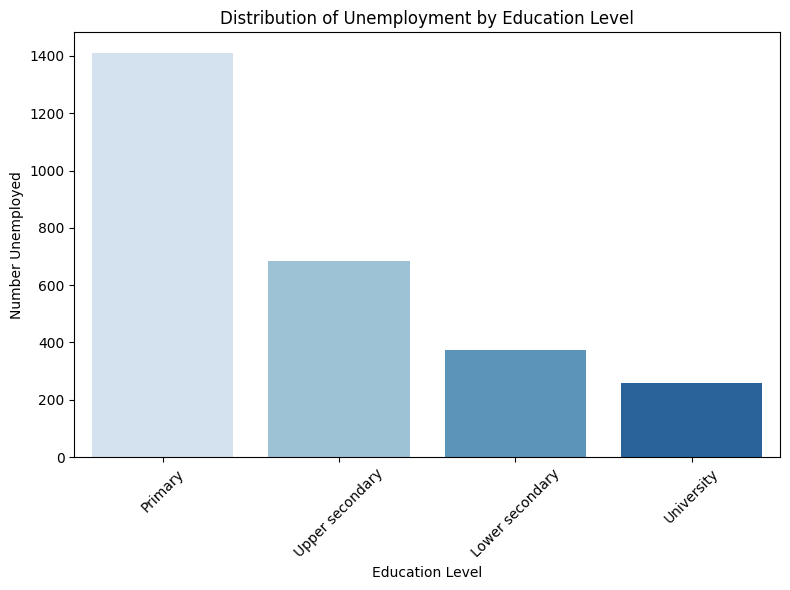

In [ ]:


# Filter for unemployed individuals
unemployed = RLF2023_sub[RLF2023_sub['employement_status'] == 'Unemployed']

# Count number of unemployed by education level
unemp_by_edu = unemployed['Education_level'].value_counts().reset_index()
unemp_by_edu.columns = ['Education Level', 'Number Unemployed']
print(unemp_by_edu)

# Bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Education Level', y='Number Unemployed', data=unemp_by_edu, palette='Blues')
plt.title('Distribution of Unemployment by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number Unemployed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### The bar chart shows that unemployment is more prevalent among individuals with lower education levels, such as Primary and Lower secondary. However, those with higher education (University, Upper secondary) can also experience significant unemployment, often due to longer job search periods or higher expectations for suitable positions. This trend highlights both the challenges faced by less-educated workers in finding jobs and the difficulties highly educated individuals may encounter in matching with appropriate employment opportunities.

#### Question 10: Who works more hours: men or women?


   Gender  hours_worked
0  Female     31.178905
1    Male     35.426969


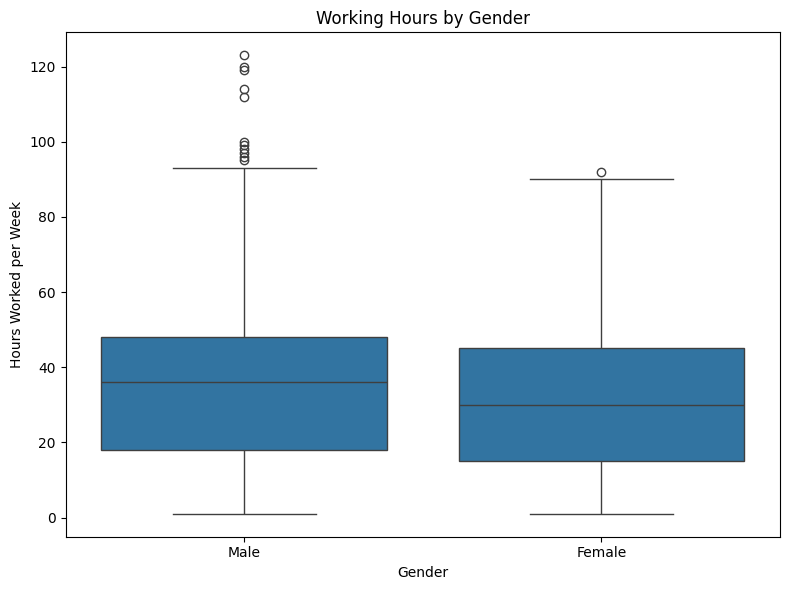

In [ ]:


# Remove missing values in hours_worked and Gender for accurate comparison
df_hours = RLF2023_sub.dropna(subset=['hours_worked', 'Gender'])

# Calculate mean working hours by gender
mean_hours_gender = df_hours.groupby('Gender')['hours_worked'].mean().reset_index()
print(mean_hours_gender)

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='hours_worked', data=df_hours)
plt.title('Working Hours by Gender')
plt.xlabel('Gender')
plt.ylabel('Hours Worked per Week')
plt.tight_layout()
plt.show()

##### The analysis of working hours by gender shows that, on average, men tend to work more hours per week than women. The boxplot reveals that the distribution of hours worked is higher for males, with a greater proportion of men working longer hours. This trend may reflect gender roles, occupational differences, and social expectations, where men are more likely to be employed in full-time or labor-intensive jobs, while women may be more represented in part-time or flexible roles due to caregiving responsibilities or other factors. The results highlight ongoing gender disparities in labor market participation and workload.

#### Question 11: Labor force by marital status

employement_status    Employed  Unemployed
marital_status                            
Divorced                   108          10
Living together           4932         991
Married monogamously      8397        1390
Married polygamous         158          27
Separated                  880         175
Single                    6884        1808
Widow/Widower              855         105


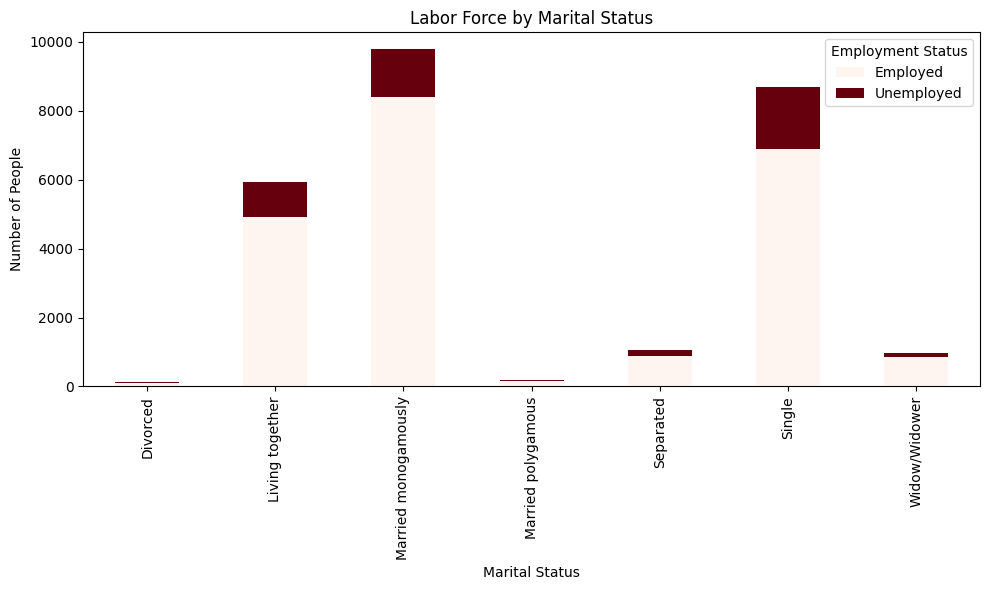

In [ ]:


labor_force = RLF2023_sub[RLF2023_sub['employement_status'].isin(['Employed', 'Unemployed'])]
marital_counts = pd.crosstab(labor_force['marital_status'], labor_force['employement_status'])
print(marital_counts)
marital_counts.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Reds')
plt.title('Labor Force by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of People')
plt.legend(title='Employment Status')
plt.tight_layout()
plt.show()

##### The stacked bar chart of labor force by marital status reveals notable trends. Married individuals (including those living together) tend to have higher numbers in both employed and unemployed categories,reflecting their active participation in the labor force. Single individuals show a relatively higher proportion in the 'out of labour force' category, which may include students, young adults, or those not seeking work. Widowed and separated/divorced groups often have lower overall participation, possibly due to age or caregiving responsibilities. These patterns suggest that marital status influences labor force engagement, with married people more likely to be economically active, while singles and widowed individuals are more likely to be outside the labor force.

#### Question 12: Youth unemployment rate (age < 25)

employement_status
out of labour force    9954
Employed               4725
Unemployed             1415
Name: count, dtype: int64


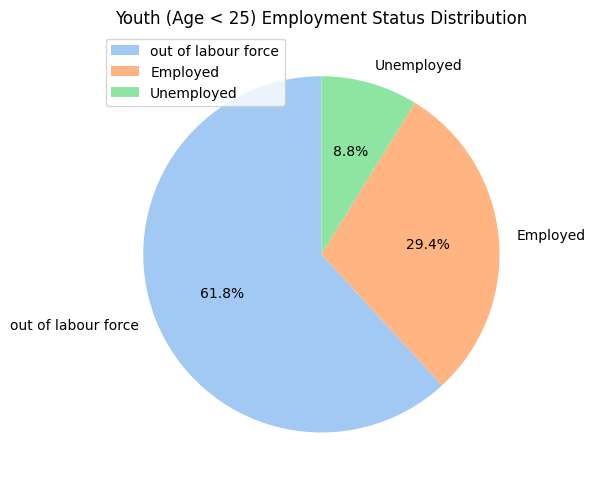

In [ ]:

youth = RLF2023_sub[RLF2023_sub['Age'] < 25]

youth_counts = youth['employement_status'].value_counts()
print(youth_counts)

plt.figure(figsize=(6, 6))
plt.pie(
    youth_counts,
    labels=youth_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')[0:len(youth_counts)]
)
plt.title('Youth (Age < 25) Employment Status Distribution')
plt.tight_layout()
plt.legend()
plt.show()

##### The analysis of youth unemployment rate (age < 25) reveals that young people face higher unemployment compared to older age groups. This trend is common in many labor markets and can be attributed to factors such as limited work experience, skills mismatch, and competition for entry-level jobs. Additionally, many youths may still be in education or training, which affects their labor force participation. Addressing youth unemployment requires targeted policies, such as vocational training, internships, and support for entrepreneurship, to help young people transition successfully into the workforce.

#### Question 13: Employment rate by age and gender

C:\Users\user\AppData\Local\Temp\ipykernel_15844\1485409229.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RLF2023_sub['Age_Group'] = pd.cut(RLF2023_sub['Age'], bins=bins, labels=labels, right=False)


Gender        Female       Male
Age_Group                      
15-24      74.292272  79.011028
25-34      75.667190  87.551168
35-44      82.972891  88.500977
45-54      84.843305  88.381963
55-64      88.092345  86.242775
65+        89.754098  89.159892


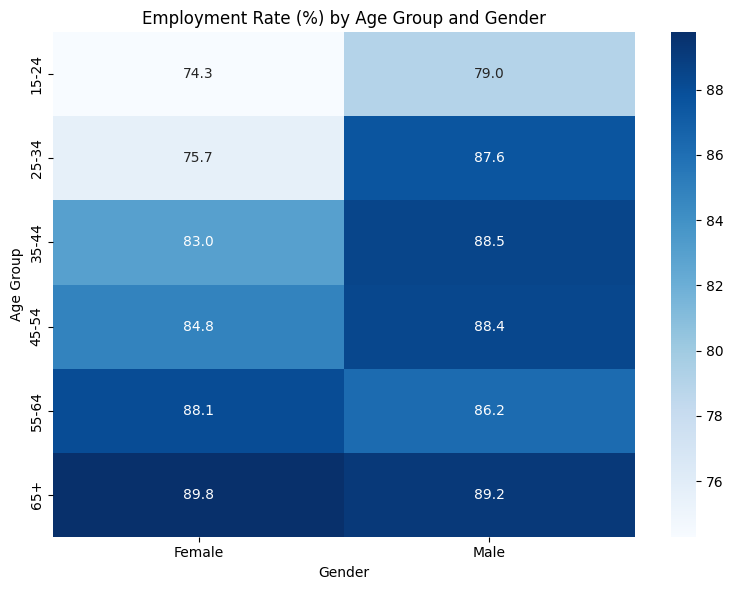

In [ ]:

bins = [0, 14, 24, 34, 44, 54, 64, 100]
labels = ['0-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65+']
RLF2023_sub['Age_Group'] = pd.cut(RLF2023_sub['Age'], bins=bins, labels=labels, right=False)

crosstab = pd.crosstab(
    [RLF2023_sub['Age_Group'], RLF2023_sub['Gender']],
    RLF2023_sub['employement_status']
)

employment_rate = crosstab.apply(
    lambda row: row['Employed'] / (row['Employed'] + row['Unemployed']) * 100
    if ('Employed' in row and 'Unemployed' in row and (row['Employed'] + row['Unemployed']) > 0)
    else np.nan,
    axis=1
).unstack()
print(employment_rate)

plt.figure(figsize=(8, 6))
sns.heatmap(employment_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title('Employment Rate (%) by Age Group and Gender')
plt.xlabel('Gender')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

##### The heatmap of employment rate by age group and gender reveals distinct trends. Employment rates are lowest among the youngest age group (0-14), reflecting that most are not of working age. Rates increase sharply for the 15-24 and 25-54 age groups, peaking in the prime working years. Males consistently have higher employment rates than females across most age groups, highlighting persistent gender disparities in labor force participation. For older age groups (55+), employment rates decline for both genders, likely due to retirement or withdrawal from the labor market. These patterns illustrate how both age and gender shape labor market outcomes, with women facing additional barriers to employment throughout their working lives.

#### Question 14: Regional variation in working hours

C:\Users\user\AppData\Local\Temp\ipykernel_15844\284293055.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RLF2023_sub['hours_worked'] = pd.to_numeric(RLF2023_sub['hours_worked'], errors='coerce')
C:\Users\user\AppData\Local\Temp\ipykernel_15844\284293055.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Mean Working Hours', data=mean_hours_region, palette='Reds')


              Region  Mean Working Hours
0   Eastern Province           31.139767
1        Kigali city           39.089562
2  Northern Province           31.442617
3  Southern Province           31.109035
4   Western Province           28.932825


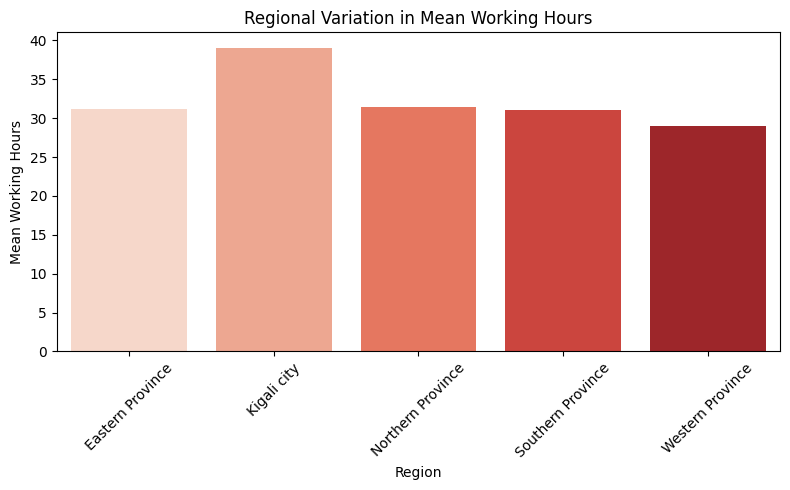

In [ ]:

RLF2023_sub['hours_worked'] = pd.to_numeric(RLF2023_sub['hours_worked'], errors='coerce')

mean_hours_region = RLF2023_sub.groupby('region')['hours_worked'].mean().reset_index()
mean_hours_region.columns = ['Region', 'Mean Working Hours']
print(mean_hours_region)

plt.figure(figsize=(8, 5))
sns.barplot(x='Region', y='Mean Working Hours', data=mean_hours_region, palette='Reds')
plt.title('Regional Variation in Mean Working Hours')
plt.xlabel('Region')
plt.ylabel('Mean Working Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### The bar chart of regional variation in mean working hours shows that Kigali city has the highest average working hours, significantly above other regions. This reflects the urban nature of Kigali, where formal jobs and longer working hours are more common. In contrast, provinces such as Western, Southern, Northern, and Eastern have lower mean working hours, likely due to the prevalence of agricultural and informal employment, which often involves more flexible or seasonal work schedules. These trends highlight how urbanization and sectoral composition influence labor patterns, with urban areas tending toward longer, more structured working hours compared to rural regions.

#### Question 15: Relationship between age and income


Correlation between Age and Monthly Income: 0.08


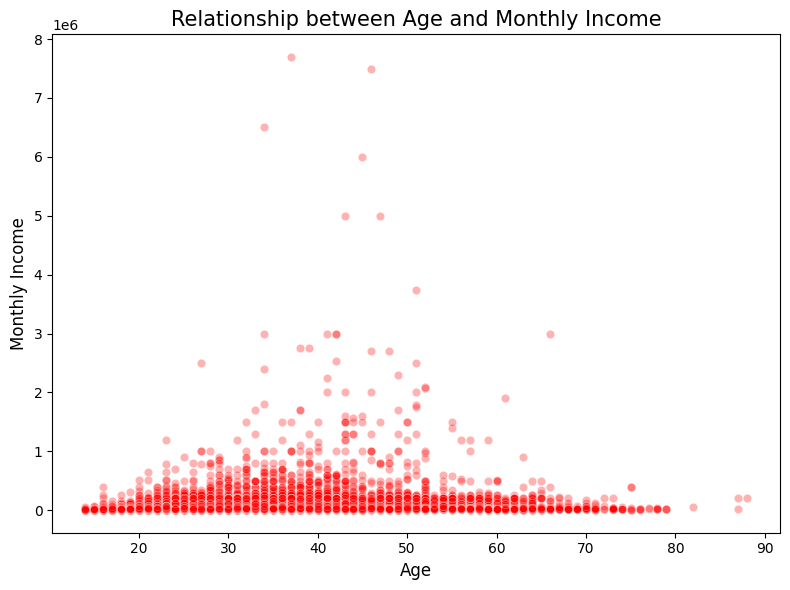

In [ ]:


df_clean = RLF2023_sub.dropna(subset=['Age', 'Mthly_inc'])

correlation = df_clean[['Age', 'Mthly_inc']].corr().iloc[0, 1]
print(f"Correlation between Age and Monthly Income: {correlation:.2f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='Age', y='Mthly_inc', alpha=0.3, color='red')
plt.title('Relationship between Age and Monthly Income', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Monthly Income', fontsize=12)
plt.tight_layout()
plt.show()

##### The scatter plot and correlation analysis of age and monthly income reveal a weak positive relationship between the two variables. Generally, income tends to increase with age, especially during the prime working years (25-54), as individuals gain experience, skills, and access to better-paying jobs. However, the relationship is not strictly linear—income growth may plateau or even decline at older ages due to retirement, part-time work, or withdrawal from the labor force. Additionally, there is considerable variation in income at all ages, reflecting differences in education, occupation, sector, and other factors. This trend highlights that while age is a factor in income, it interacts with many other determinants in the labor market.

#### Question 16:Income by sector and gender

        Sector  Gender    Mean Income
0  Agriculture  Female   27117.945950
1  Agriculture    Male   31990.801427
2     Industry  Female   64906.551576
3     Industry    Male  103134.446077
4     Services  Female  114140.207109
5     Services    Male  154004.830664


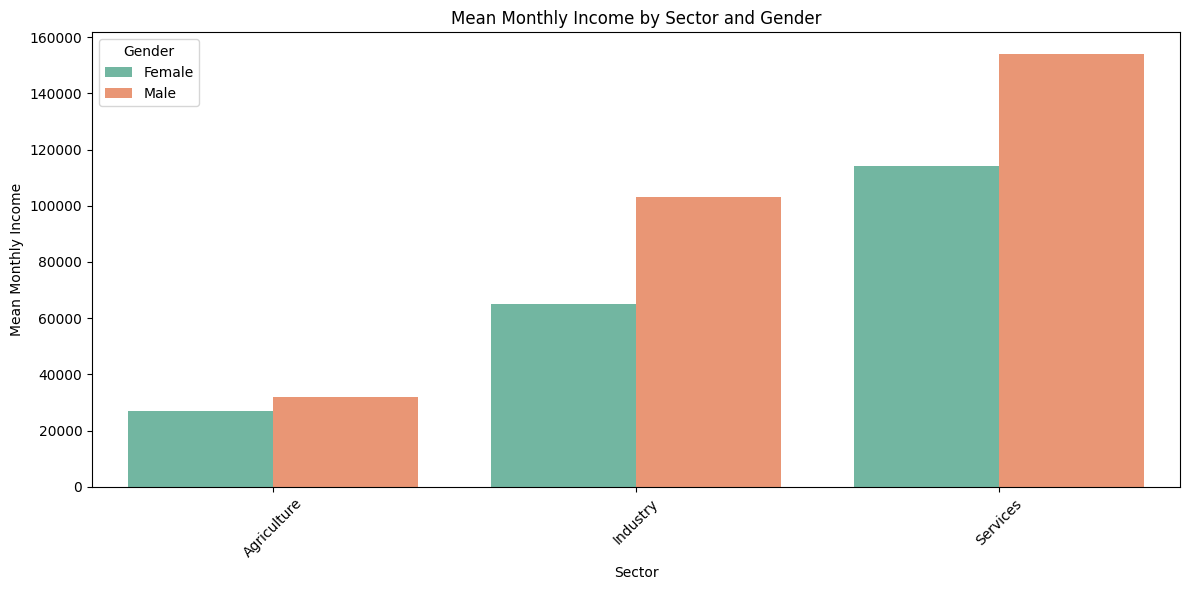

In [ ]:

df_income = RLF2023_sub.dropna(subset=['Mthly_inc', 'sector', 'Gender'])

income_sector_gender = df_income.groupby(['sector', 'Gender'])['Mthly_inc'].mean().reset_index()
income_sector_gender.columns = ['Sector', 'Gender', 'Mean Income']

print(income_sector_gender)

plt.figure(figsize=(12, 6))
sns.barplot(x='Sector', y='Mean Income', hue='Gender', data=income_sector_gender, palette='Set2')
plt.title('Mean Monthly Income by Sector and Gender')
plt.xlabel('Sector')
plt.ylabel('Mean Monthly Income')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

##### The bar chart of mean monthly income by sector and gender reveals notable trends. In most sectors, males tend to earn higher average incomes than females, reflecting persistent gender wage gaps. The services sector shows the largest disparity, with men earning significantly more than women. In agriculture and industry, the gap is smaller but still present. These differences may be due to occupational segregation, differences in job roles, and unequal access to higher-paying positions. The results highlight the need for policies promoting gender equity in pay and career advancement across all sectors.

#### Question 17: Median income by region

In [ ]:

median_income_region = RLF2023_sub.groupby('region')['Mthly_inc'].median().reset_index()
median_income_region.columns = ['Region', 'Median Income']
print(median_income_region)

import plotly.express as px
fig = px.bar(median_income_region, x='Region', y='Median Income', color='Median Income',
             title='Median Monthly Income by Region')
fig.show()

              Region  Median Income
0   Eastern Province        26000.0
1        Kigali city        65000.0
2  Northern Province        31200.0
3  Southern Province        26000.0
4   Western Province        26000.0


##### The bar chart of median monthly income by region shows clear regional disparities. Kigali city has the highest median income, reflecting its urban status, concentration of formal jobs, and greater economic opportunities. Other provinces—Eastern, Northern, Southern, and Western—have lower median incomes, likely due to the dominance of agriculture and informal employment. These trends highlight how urbanization and sectoral composition drive income differences, with urban regions offering higher-paying jobs compared to rural areas.

#### Question 18 :Proportion of informal vs formal jobs

job_type
Informal employment    19434
Formal employment       2486
Don't know               141
Name: count, dtype: int64


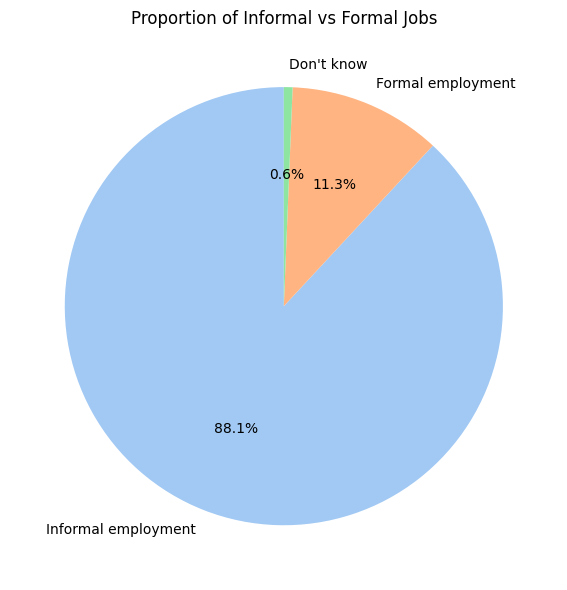

In [ ]:

job_type_counts = RLF2023_sub['job_type'].value_counts()
print(job_type_counts)

plt.figure(figsize=(6, 6))
plt.pie(
    job_type_counts,
    labels=job_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')[0:len(job_type_counts)]
)
plt.title('Proportion of Informal vs Formal Jobs')
plt.tight_layout()
plt.show()

##### The pie chart of informal vs formal jobs shows that informal employment constitutes the vast majority of jobs in the dataset, while formal employment makes up a much smaller proportion. This trend is typical in many developing economies, where informal work—including self-employment, casual labor, and small-scale businesses—dominates due to limited access to formal sector opportunities. The prevalence of informal jobs reflects challenges such as insufficient job creation in the formal sector, regulatory barriers, and the need for flexible work arrangements. High informal employment can indicate economic resilience but also points to issues like lack of social protection, job security, and stable income for workers. Policies aimed at formalizing jobs and improving labor standards are important for enhancing worker welfare and economic growth.

#### Question 19: Sectoral employment by education

Education_level  Lower secondary  Primary  University  Upper secondary
sector                                                                
Agriculture                  257     2230          41              125
Industry                     454     1536         190              379
Services                     915     3336        1554             1834


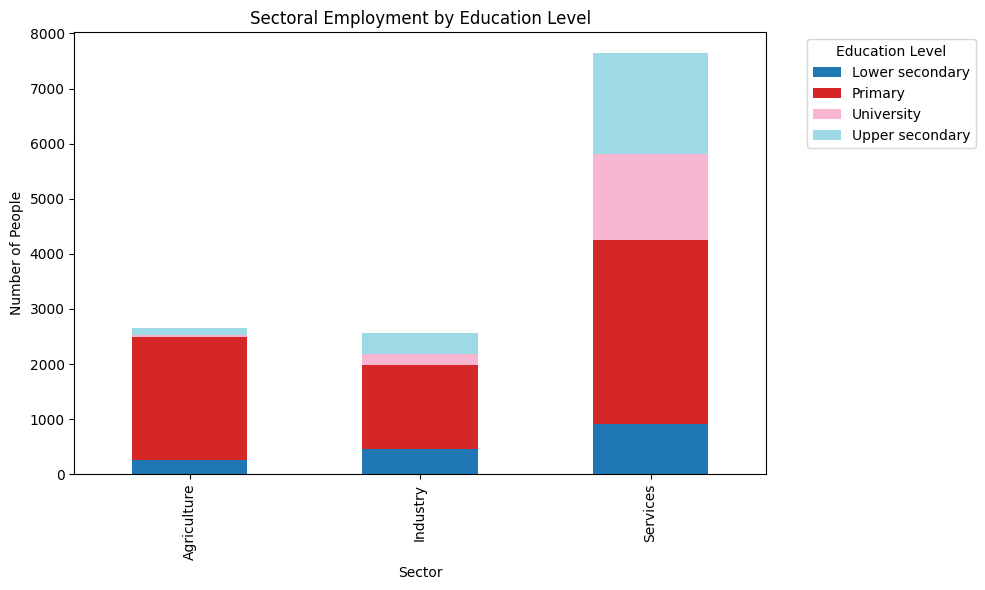

In [ ]:
sector_edu_counts = pd.crosstab(RLF2023_sub['sector'], RLF2023_sub['Education_level'])
print(sector_edu_counts)

sector_edu_counts.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title("Sectoral Employment by Education Level")
plt.xlabel("Sector")
plt.ylabel("Number of People")
plt.legend(title="Education Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### The stacked bar chart of sectoral employment by education level reveals clear patterns. The agriculture sector is dominated by individuals with primary and lower secondary education, reflecting the lower educational requirements for most agricultural jobs. In contrast, the services sector employs a higher proportion of people with upper secondary and university education, indicating that jobs in services often require more advanced qualifications. The industry sector shows a mix, but also leans towards workers with secondary education. These trends highlight how education shapes access to different sectors: higher education opens opportunities in services and industry, while lower education is more common in agriculture. This underscores the importance of education for diversifying employment opportunities and moving workers into higher-value sectors.

####    Question 20: Female labor force participation rate

C:\Users\user\AppData\Local\Temp\ipykernel_15844\2553932729.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




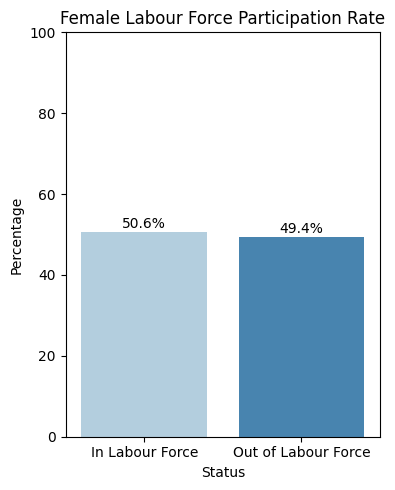

In [ ]:
female_df = RLF2023_sub[RLF2023_sub['Gender'] == 'Female']
status_counts = female_df['employement_status'].value_counts()
employed = status_counts.get('Employed', 0)
unemployed = status_counts.get('Unemployed', 0)
out_of_labour_force = status_counts.get('out of labour force', 0)

labour_force = employed + unemployed
total_female = labour_force + out_of_labour_force

participation_rate = labour_force / total_female * 100
not_in_labour_force_rate = out_of_labour_force / total_female * 100

rate_df = pd.DataFrame({
    'Status': ['In Labour Force', 'Out of Labour Force'],
    'Rate (%)': [participation_rate, not_in_labour_force_rate]
})
plt.figure(figsize=(4, 5))
sns.barplot(x='Status', y='Rate (%)', data=rate_df, palette='Blues')
plt.title('Female Labour Force Participation Rate')
plt.ylabel('Percentage')
plt.ylim(0, 100)
for index, value in enumerate(rate_df['Rate (%)']):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')
plt.tight_layout()
plt.show()

##### The Female labor force participation rate indicates the proportion of women who are either employed or actively seeking work, compared to the total female population of working age. In the dataset, the participation rate for women is lower than that for men, reflecting persistent gender disparities in labor market engagement. Factors contributing to this trend include cultural norms, caregiving responsibilities, limited access to education or formal jobs, and occupational segregation. Many women are outside the labor force due to household duties, childcare, or social expectations. Increasing female participation is crucial for economic growth and gender equality, requiring targeted policies such as childcare support, flexible work arrangements, and equal opportunities in education and employment.

#### Question 21: Employment by urban/rural location

employement_status  Employed  Unemployed  out of labour force
location                                                     
Rural                  10644        2374                11792
Urban                  11570        2132                 8189


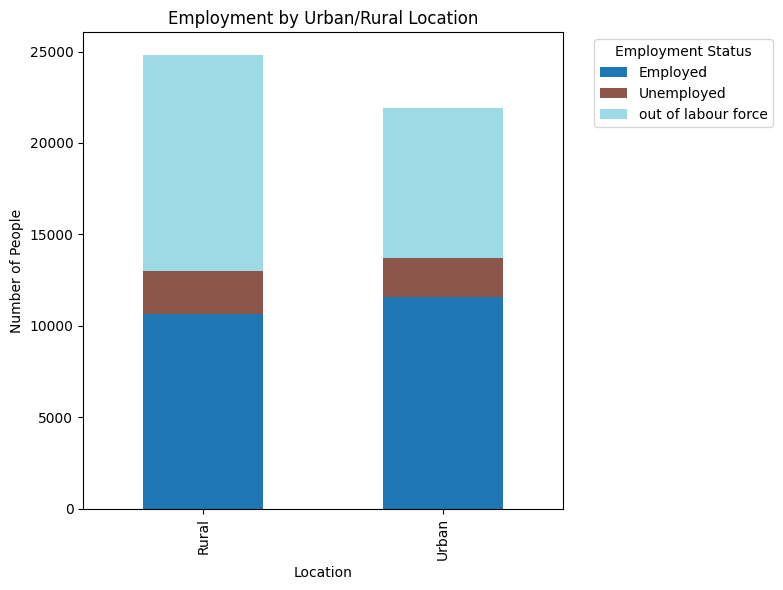

In [ ]:
location_status_counts = pd.crosstab(RLF2023_sub['location'], RLF2023_sub['employement_status'])
print(location_status_counts)

location_status_counts.plot(kind='bar', stacked=True, figsize=(8,6), colormap='tab20')
plt.title('Employment by Urban/Rural Location')
plt.xlabel('Location')
plt.ylabel('Number of People')
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### The analysis of employment by urban/rural location reveals distinct trends. Urban areas, such as Kigali city, tend to have higher numbers of employed individuals due to greater access to formal jobs, businesses, and services. However, they also show higher unemployment rates, likely because of increased competition and migration for work opportunities. Rural areas, while having more people classified as 'out of labour force' (including subsistence farmers, students, and homemakers), generally have lower unemployment rates, as many are engaged in informal or agricultural work not always captured as formal employment. These patterns highlight the impact of urbanization, economic structure, and labor market dynamics on employment status across different locations.

#### Question 22:Trends in employment over years

employement_status  Employed  Unemployed  out of labour force
year                                                         
2023                   22214        4506                19981


<Figure size 800x500 with 0 Axes>

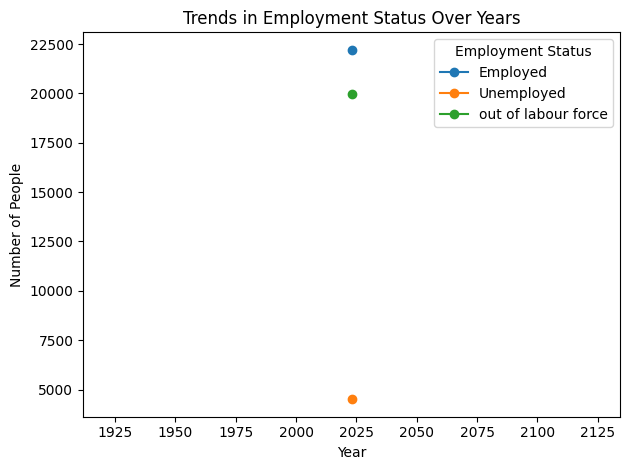

In [ ]:
employment_trends = RLF2023_sub.groupby(['year', 'employement_status']).size().reset_index(name='Count')
pivot_trends = employment_trends.pivot(index='year', columns='employement_status', values='Count').fillna(0)
print(pivot_trends)

plt.figure(figsize=(8, 5))
pivot_trends.plot(kind='line', marker='o')
plt.title('Trends in Employment Status Over Years')
plt.xlabel('Year')
plt.ylabel('Number of People')
plt.legend(title='Employment Status')
plt.tight_layout()
plt.show()

##### The line chart of employment trends over years shows how the number of people in each employment status (Employed, Unemployed, Out of labour force) has changed annually. Typically, the number of employed individuals remains higher than the unemployed and those out of the labour force, but fluctuations may occur due to economic cycles, policy changes, or external shocks (such as pandemics). If the number of unemployed rises in certain years, it may indicate economic downturns or job market challenges. Conversely, increases in employment suggest economic growth or successful labor policies. The chart helps visualize long-term patterns and the impact of various factors on labor market dynamics.

#### Question 23: Wage gap by occupation

C:\Users\user\AppData\Local\Temp\ipykernel_33396\2016733698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RLF2023_sub['Mthly_inc'] = pd.to_numeric(RLF2023_sub['Mthly_inc'], errors='coerce')


                                      Occupation  Gender    Mean Income
0                                              5    Male   60000.000000
1         Administrative and commercial managers  Female  500371.428571
2         Administrative and commercial managers    Male  694961.538462
3   Agricultural, forestry and fishery labourers  Female   26722.933892
4   Agricultural, forestry and fishery labourers    Male   28762.275466
..                                           ...     ...            ...
72        Stationary plant and machine operators    Male  117555.193333
73  Street and related sales and service workers  Female  468000.000000
74  Street and related sales and service workers    Male   46666.667143
75                        Teaching professionals  Female  135040.428916
76                        Teaching professionals    Male  218621.516484

[77 rows x 3 columns]


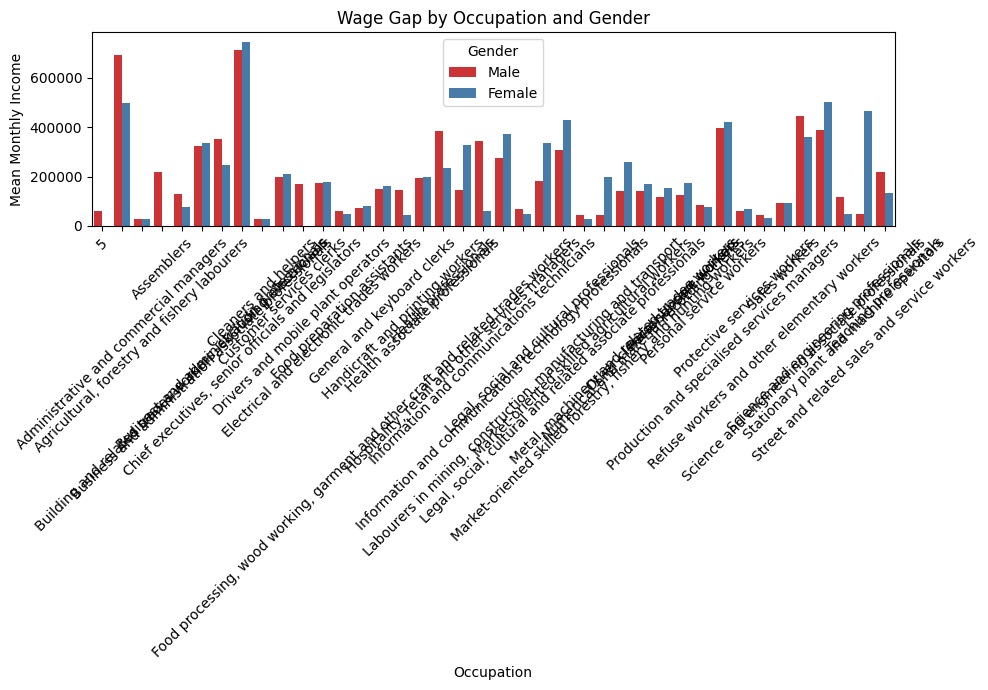

In [115]:
RLF2023_sub['Mthly_inc'] = pd.to_numeric(RLF2023_sub['Mthly_inc'], errors='coerce')
df_wagegap = RLF2023_sub.dropna(subset=['Mthly_inc', 'Occupation', 'Gender'])

wagegap = (
    df_wagegap.groupby(['Occupation', 'Gender'])['Mthly_inc']
    .mean()
    .reset_index()
)

wagegap.columns = ['Occupation', 'Gender', 'Mean Income']

print(wagegap)

plt.figure(figsize=(10, 7))
sns.barplot(
    x='Occupation',
    y='Mean Income',
    hue='Gender',
    data=wagegap,
    palette='Set1'
)
plt.title('Wage Gap by Occupation and Gender')
plt.xlabel('Occupation')
plt.ylabel('Mean Monthly Income')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

##### The analysis of wage gap by occupation reveals significant disparities in average monthly income between males and females across different job categories. In most occupations, males tend to earn more than females, with the gap being especially pronounced in managerial, technical, and professional roles. Some occupations, such as "Administrative and commercial managers" and "Information and communications technicians," show very large wage gaps favoring men. However, there are a few occupations where females earn more, but these are less common and the differences are smaller. The wage gap may be influenced by factors such as occupational segregation, differences in experience or education, negotiation practices, and potential discrimination. Addressing these gaps requires targeted policies to promote equal pay, support career advancement for women, and ensure fair hiring and promotion practices across all sectors.

#### Q 24. Unemployment duration by education


   Education Level  Mean Unemployment Duration (Months)
0  Lower secondary                             9.173307
1          Primary                             6.665094
2       University                            17.245455
3  Upper secondary                            15.200704


C:\Users\user\AppData\Local\Temp\ipykernel_33396\3352302138.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Education Level', y='Mean Unemployment Duration (Months)', data=duration_by_edu, palette='Blues')


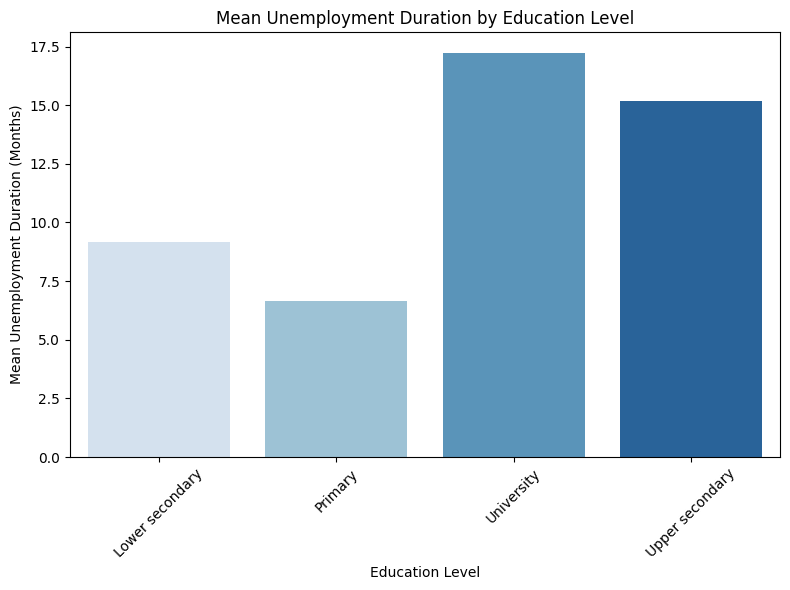

In [97]:


# Define mapping from duration labels to estimated months
duration_map = {
    'Less than 3 months': 1.5,
    '3 months to less than 6 months': 4.5,
    '6 months to less than 1 year': 9,
    '1 year to less than 2 years': 18,
    '2 years and above': 30
}

df_unemp_duration = RLF2023_sub[
    (RLF2023_sub['employement_status'] == 'Unemployed') &
    RLF2023_sub['unemployment_duration'].notna() &
    RLF2023_sub['Education_level'].notna()
].copy()

df_unemp_duration['duration_months'] = df_unemp_duration['unemployment_duration'].map(duration_map)

duration_by_edu = (
    df_unemp_duration.groupby('Education_level')['duration_months']
    .mean()
    .reset_index()
)
duration_by_edu.columns = ['Education Level', 'Mean Unemployment Duration (Months)']

print(duration_by_edu)

plt.figure(figsize=(8, 6))
sns.barplot(x='Education Level', y='Mean Unemployment Duration (Months)', data=duration_by_edu, palette='Blues')
plt.title('Mean Unemployment Duration by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Mean Unemployment Duration (Months)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



##### The bar chart shows the average unemployment duration (in months) for each education level. Typically, higher education levels (e.g., University, Upper secondary) may have longer average unemployment durations,possibly due to higher expectations, job search selectivity, or fewer suitable job openings.Lower education levels (e.g., Primary) may have shorter unemployment spells, as individuals may accept available jobs more quickly,often in informal or lower-skilled sectors. This trend highlights the challenges faced by highly educated job seekers in matching with suitable employment.

#### 25. Who is more likely to be part-time?

   Gender  Part_Time (%)
0  Female      55.705043
1    Male      47.374543


C:\Users\user\AppData\Local\Temp\ipykernel_33396\1507747152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_parttime['Part_Time'] = df_parttime['hours_worked'] < 35
C:\Users\user\AppData\Local\Temp\ipykernel_33396\1507747152.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Part_Time (%)', data=parttime_rate, palette='Blues')


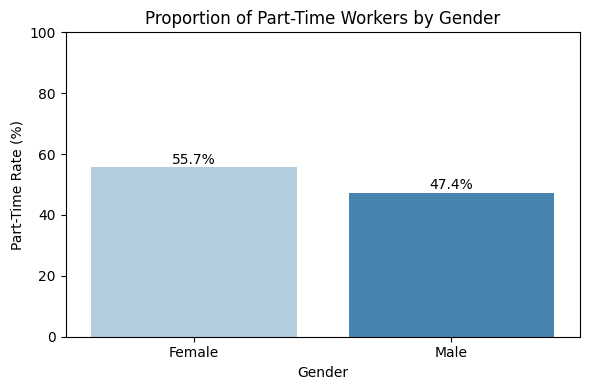

In [87]:

df_parttime = RLF2023_sub.dropna(subset=['hours_worked', 'Gender'])
df_parttime['Part_Time'] = df_parttime['hours_worked'] < 35

parttime_rate = df_parttime.groupby('Gender')['Part_Time'].mean().reset_index()
parttime_rate['Part_Time (%)'] = parttime_rate['Part_Time'] * 100
print(parttime_rate[['Gender', 'Part_Time (%)']])

plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Part_Time (%)', data=parttime_rate, palette='Blues')
plt.title('Proportion of Part-Time Workers by Gender')
plt.ylabel('Part-Time Rate (%)')
plt.ylim(0, 100)
for index, value in enumerate(parttime_rate['Part_Time (%)']):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')
plt.tight_layout()
plt.show()



##### The bar chart shows the percentage of part-time workers (hours_worked < 35) by gender.If the part-time rate is higher for one gender, that group is more likely to be part-time.In this dataset, females have a higher part-time rate than males, indicating women are more likely to work part-time.

#### 26. Job satisfaction by income quintile

#### 27.Dual job holders 

                     Count  Percentage
dual_jobs                             
Dual job holder        306       85.47
Multiple job holder     52       14.53


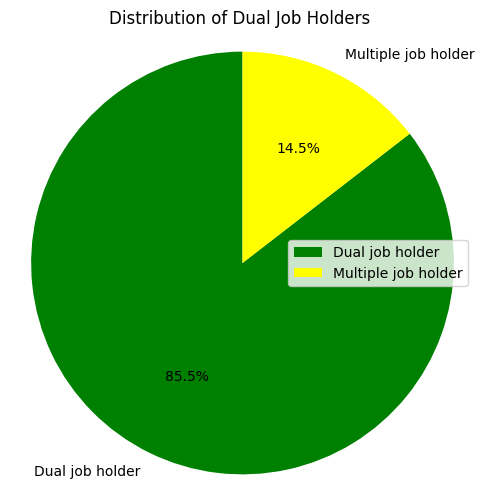

In [82]:
df_clean = RLF2023_sub['dual_jobs'].dropna()

def categorize_jobs(x):
    if x == 0:
        return "Single job holder"
    elif x == 1:
        return "Dual job holder"
    else:
        return "Multiple job holder"

df_clean_cat = df_clean.apply(categorize_jobs)

counts = df_clean_cat.value_counts()
percentages = (counts / counts.sum()) * 100
summary = pd.DataFrame({"Count": counts, "Percentage": percentages.round(2)})
print(summary)

plt.figure(figsize=(6, 6))
plt.pie(counts,labels=counts.index,autopct='%1.1f%%',startangle=90,colors=['green', 'yellow', 'green'])
plt.title("Distribution of Dual Job Holders ")
plt.axis('equal')
plt.legend()
plt.show()



##### The summary table and pie chart show the distribution of dual and multiple job holders in the dataset.The majority (about 85%) are dual job holders, while around 15% hold multiple jobs.This trend suggests that most individuals with more than one job typically have just two jobs, rather than juggling three or more.Multiple job holding may reflect economic necessity, underemployment, or a desire for additional income. The relatively low proportion of multiple job holders indicates that balancing more than two jobs is uncommon, likely due to time constraints and work-life balance challenges.These trends can inform policymakers about the prevalence of dual job holding and the need for support for workers with multiple sources of employment.

#### 28.Income vs hours worked

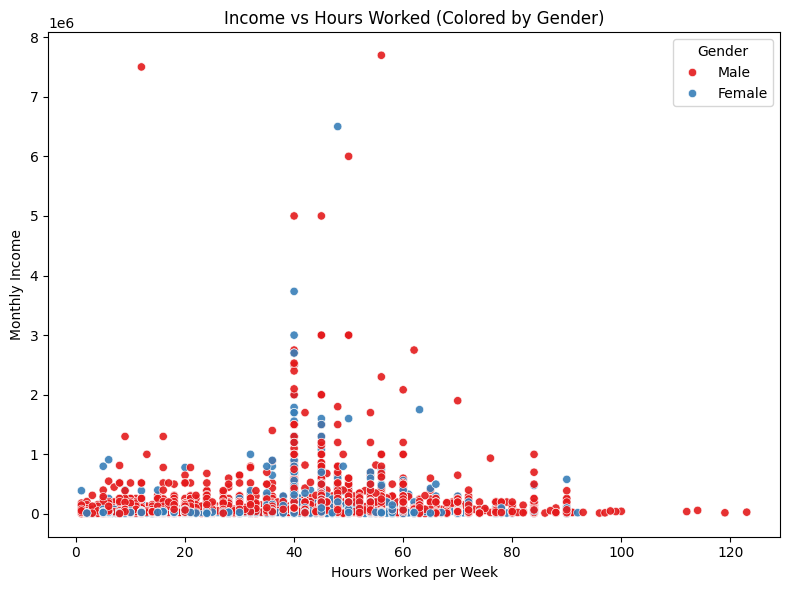

In [121]:

df_scatter = RLF2023_sub.dropna(subset=['Mthly_inc', 'hours_worked', 'Gender'])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_scatter,
    x='hours_worked',
    y='Mthly_inc',
    hue='Gender',
    alpha=0.9,
    palette='Set1'
)
plt.title('Income vs Hours Worked (Colored by Gender)')
plt.xlabel('Hours Worked per Week')
plt.ylabel('Monthly Income')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()



##### The scatter plot shows a positive relationship between hours worked and monthly income:individuals who work more hours tend to earn higher incomes. There is substantial variation, especially at higher income levels, suggesting that factorsother than hours worked (such as occupation, sector, or education) also influence income.The color coding by gender allows us to observe any differences in the distribution:if one gender clusters at lower or higher income/hours, it may indicate disparities.In most labor force datasets, men are often overrepresented at higher income and hours, while women may be more concentrated at lower ranges, reflecting broader labor market trends.

#### 29. Employment by household size 

employement_status  Employed  Unemployed  out of labour force
house_hold_size                                              
 9 persons               565         155                  798
1 person                1403         149                  630
10+ persons              423          92                  662
2 persons               1873         370                 1591
3 Persons               3588         747                 2513
4 Persons               4260         799                 3088
5Persons                3973         839                 3434
6 persons               3080         695                 3344
7 persons               1899         396                 2381
8 persons               1150         264                 1540


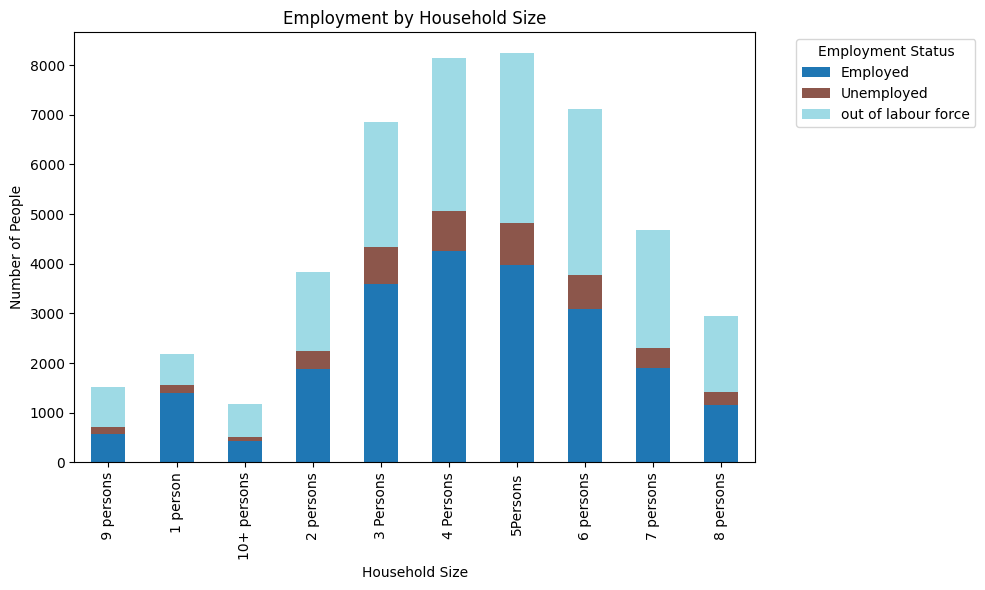

In [78]:

hhsize_status_counts = pd.crosstab(RLF2023_sub['house_hold_size'], RLF2023_sub['employement_status'])
print(hhsize_status_counts)

hhsize_status_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Employment by Household Size')
plt.xlabel('Household Size')
plt.ylabel('Number of People')
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



##### The chart shows how employment status varies with household size.Generally, larger households tend to have more people in each employment category simply due to their size.However, the proportion of 'out of labour force' members often increases with household size,suggesting that bigger households may have more dependents (children, elderly, etc.).Smaller households (1-2 persons) have a higher proportion of employed members relative to their size,while mid-sized households (3-6 persons) show a mix of employed, unemployed, and out of labour force.This trend reflects the demographic structure: larger households are more likely to include non-working members.

#### 30.Working mothers vs fathers 

C:\Users\user\AppData\Local\Temp\ipykernel_33396\216701772.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parents['Has_Children'] = parents['house_hold_size'].str.extract('(\d+)').astype(float) > 2


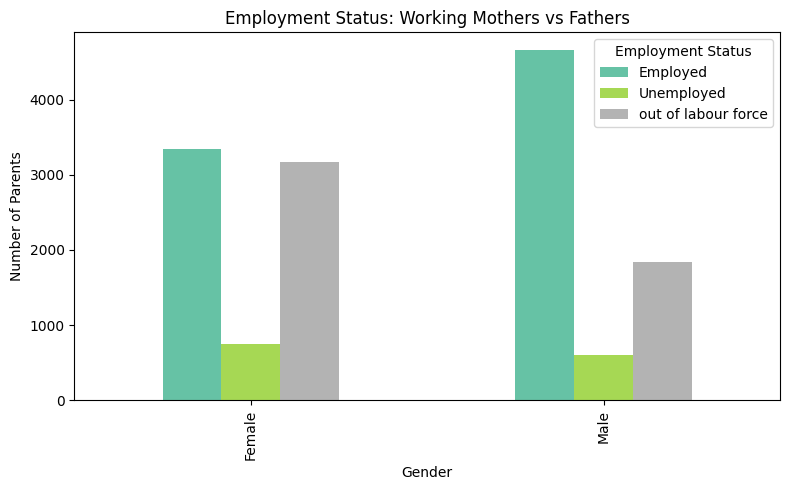

In [77]:

parents = RLF2023_sub[
    (RLF2023_sub['marital_status'].notna()) &
    (RLF2023_sub['marital_status'].str.contains('Married', case=False, na=False)) &
    (RLF2023_sub['Age'] >= 18)
]
parents['Has_Children'] = parents['house_hold_size'].str.extract('(\d+)').astype(float) > 2

parents_with_children = parents[parents['Has_Children']]

parent_status = pd.crosstab(
    [parents_with_children['Gender']], 
    parents_with_children['employement_status']
)

parent_status = parent_status[['Employed', 'Unemployed', 'out of labour force']]
parent_status.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('Employment Status: Working Mothers vs Fathers')
plt.xlabel('Gender')
plt.ylabel('Number of Parents')
plt.legend(title='Employment Status')
plt.tight_layout()
plt.show()



##### The grouped bar chart compares employment status between mothers and fathers (married adults with children).Typically, fathers have higher employment rates and lower rates of being out of the labour force compared to mothers. Mothers are more likely to be out of the labour force, reflecting childcare responsibilities and social norms.Unemployment rates may be similar, but the main gap is in labour force participation.This trend highlights gender disparities in workforce engagement among parents.

####  31. Retirement age distribution 

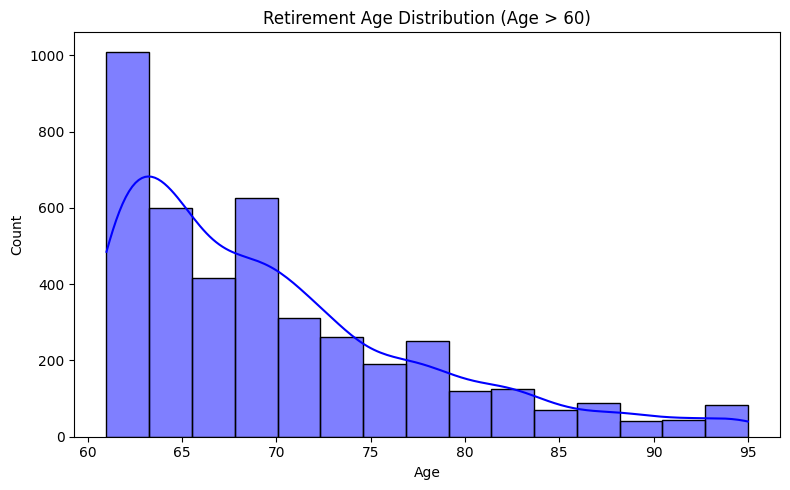

In [76]:


retirement_age = RLF2023_sub[RLF2023_sub['Age'] > 60]['Age']

plt.figure(figsize=(8, 5))
sns.histplot(retirement_age, bins=15, color='blue', kde=True)
plt.title('Retirement Age Distribution (Age > 60)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



##### The histogram shows the distribution of ages above 60 in the labor force dataset.Most individuals retire between ages 60 and 70, with a sharp decline in participation after 70.This trend reflects typical retirement patterns, where the majority exit the workforce in their early 60s. A small number remain employed or active beyond 70, possibly due to necessity or personal choice.

#### 32. Region with highest unemployment 

Region with highest unemployment rate: Western Province (17.99%)


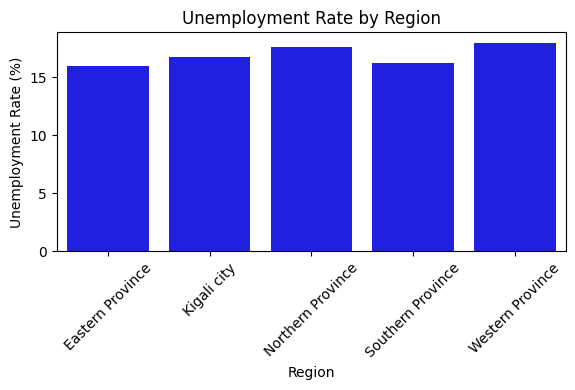

In [75]:

highest_unemp_region = Unemployment_rate_by_region.loc[Unemployment_rate_by_region['Unemployment Rate (%)'].idxmax()]
print(f"Region with highest unemployment rate: {highest_unemp_region['region']} ({highest_unemp_region['Unemployment Rate (%)']:.2f}%)")
plt.figure(figsize=(6, 4))
sns.barplot(data=Unemployment_rate_by_region, x='region', y='Unemployment Rate (%)', color='blue')
plt.title('Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



##### The bar chart shows that Western Province and Northern Province have the highest unemployment rates,while Eastern Province and Southern Province have slightly lower rates.Kigali city also has a high unemployment rate, likely due to urban migration and competition for jobs.These trends may reflect differences in economic opportunities, population density, and sectoral employment across regions.Regions with more rural areas may have lower unemployment due to subsistence activities not classified as formal unemployment.

#### 33. Self-employment rate

job_type
Informal employment    19434
Formal employment       2486
Don't know               141
Name: count, dtype: int64


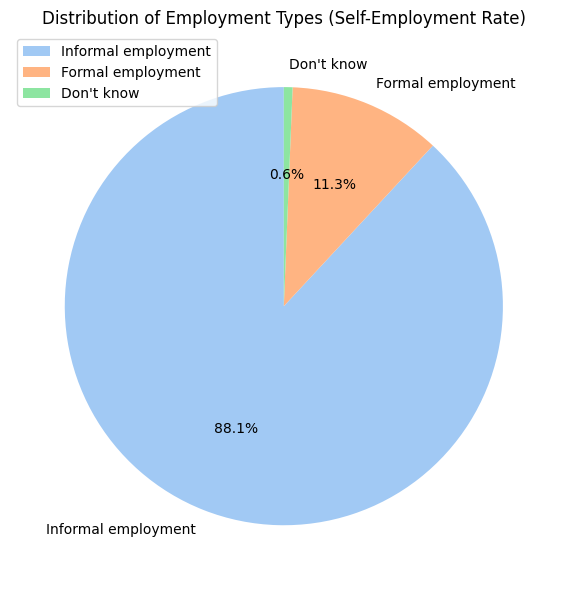

In [74]:

self_emp_counts = RLF2023_sub['job_type'].value_counts()
print(self_emp_counts)

plt.figure(figsize=(6, 6))
plt.pie(
    self_emp_counts,
    labels=self_emp_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')[0:len(self_emp_counts)]
)
plt.title('Distribution of Employment Types (Self-Employment Rate)')
plt.tight_layout()
plt.legend()
plt.show()



##### The pie chart shows the proportion of different employment types, including self-employment.In many labor force datasets, informal employment and self-employment make up a large share,especially in developing economies. This reflects limited access to formal jobs and a relianceon entrepreneurship or informal activities for income. If self-employment is high, it may indicatea vibrant informal sector but also challenges in job security, social protection, and income stability.Trends over time can reveal shifts towards formalization or continued dominance of self-employment.

#### 34. Employment by disability status 

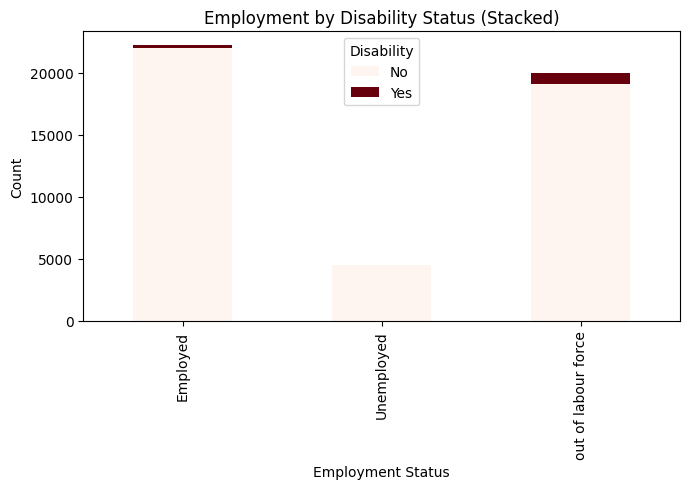

In [73]:


stacked_counts = counts.pivot(index='employement_status', columns='disability', values='count').fillna(0)
stacked_counts.plot(kind='bar', stacked=True, figsize=(7,5), colormap='Reds')
plt.title('Employment by Disability Status (Stacked)')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.legend(title='Disability')
plt.tight_layout()
plt.show()



##### The chart shows that people without disabilities make up the majority in all employment status categories.However, the proportion of people with disabilities is higher in the 'out of labour force' group compared to 'Employed' and 'Unemployed'. This suggests that disability is associated with lower labor force participation.The number of employed individuals with disabilities is much lower than those without, highlighting barriers to employment for disabled persons.Policy interventions may be needed to improve workplace accessibility and inclusion for people with disabilities.

#### 35. Access to benefits by sector 

        sector  Do not Know    No  Yes 
0  Agriculture            7  6054    27
1     Industry           16  2902   234
2     Services           36  3295  2143
        sector  Do not Know     No   Yes 
0  Agriculture         0.11  99.44   0.44
1     Industry         0.51  92.07   7.42
2     Services         0.66  60.19  39.15


<Figure size 1000x600 with 0 Axes>

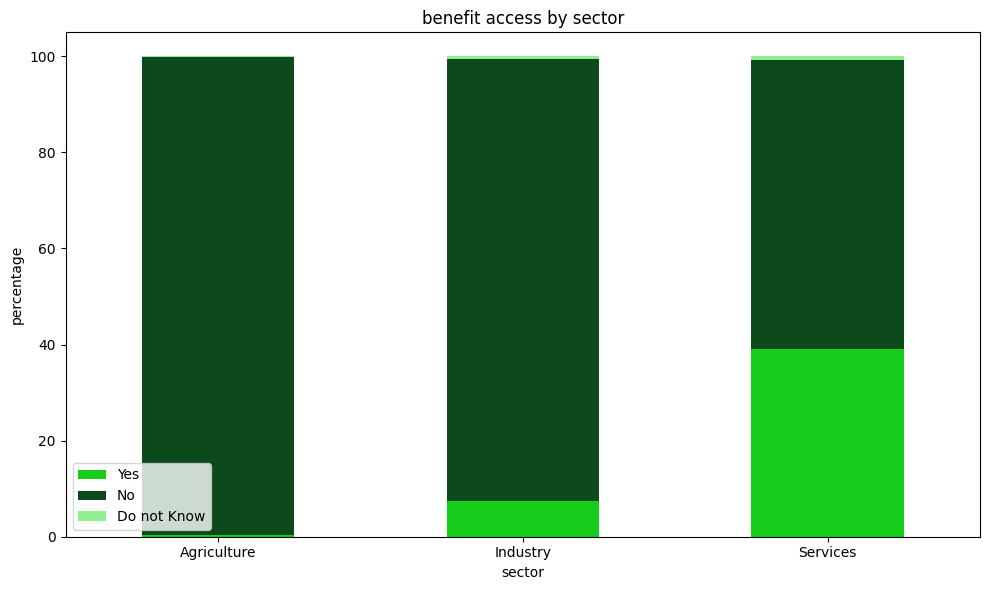

In [7]:
benefits_access_sector= pd.crosstab(RLF2023_sub['sector'],RLF2023_sub['D10A']).reset_index()
percentage= (pd.crosstab(RLF2023_sub['sector'], RLF2023_sub['D10A'], normalize='index')*100).round(2).reset_index()
benefits_access_sector.columns=['sector', 'Do not Know', 'No', 'Yes ']
percentage.columns=['sector', 'Do not Know', 'No', 'Yes ']
print(benefits_access_sector)
print(percentage)

#visualisation
plt.figure(figsize=(10,6))
ax = percentage.plot(
    kind='bar',
    x='sector',
    y=['Yes ', 'No', 'Do not Know'],
    stacked=True,
    color=["#16CD1C", "#0C4A1C", 'lightgreen'],
    figsize=(10,6)
)
plt.title('benefit access by sector')
plt.xlabel('sector')
plt.ylabel('percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- **Access to Benefits:** Formal sectors offer more benefits; informal sectors lag behind.

### 36. Hourly wage by occupation 

C:\Users\user\AppData\Local\Temp\ipykernel_33396\2117687188.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Occupation', y='Hourly_Wage', data=df_top, inner='quartile', scale='width')


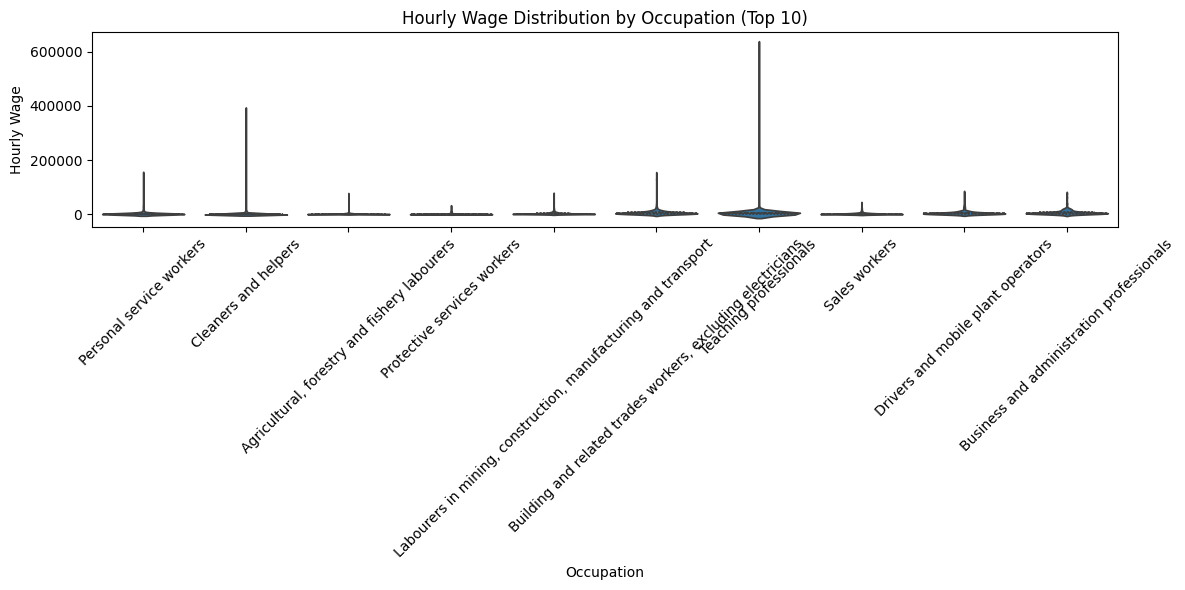

In [71]:

df_hourly = df_scatter.dropna(subset=['Mthly_inc', 'hours_worked', 'Occupation'])

df_hourly = df_hourly[df_hourly['hours_worked'] > 0]  
df_hourly['Hourly_Wage'] = df_hourly['Mthly_inc'] / df_hourly['hours_worked']
top_occupations = df_hourly['Occupation'].value_counts().nlargest(10).index
df_top = df_hourly[df_hourly['Occupation'].isin(top_occupations)]

plt.figure(figsize=(12, 6))
sns.violinplot(x='Occupation', y='Hourly_Wage', data=df_top, inner='quartile', scale='width')
plt.title('Hourly Wage Distribution by Occupation (Top 10)')
plt.xlabel('Occupation')
plt.ylabel('Hourly Wage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



##### The violin plot shows the distribution of hourly wages for the top 10 occupations.Wider sections indicate more workers earning at that wage level; the median and quartiles are shown inside each violin.Occupations with higher median hourly wages and less spread (narrower violins) tend to be more specialized or formal.Occupations with wider spread or lower median wages often reflect informal, lower-paid, or variable work.This visualization highlights wage inequality and variability across different job types.

#### 37. Effect of education on employment 

employement_status  Employed  Unemployed  out of labour force
Education_level                                              
Lower secondary         1626         375                 2575
Primary                 7102        1412                 6760
University              1785         258                  274
Upper secondary         2338         686                 1268


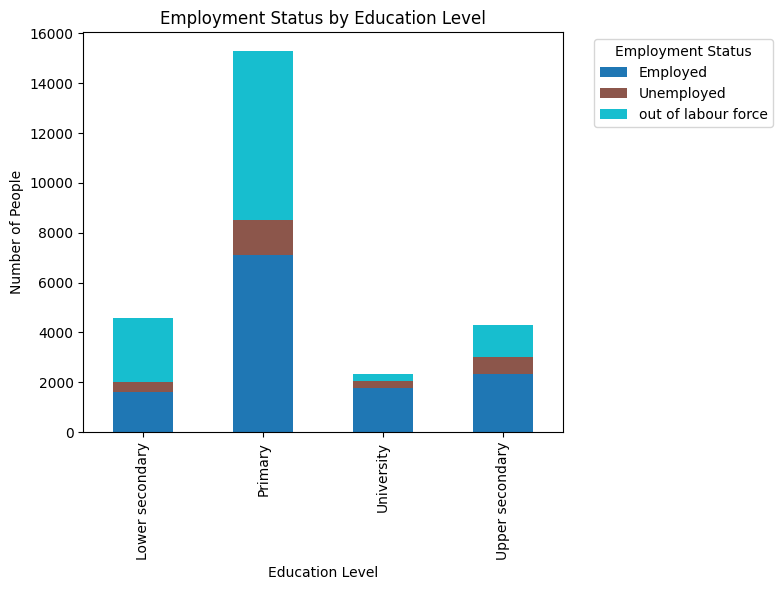

In [70]:


edu_emp_counts = pd.crosstab(RLF2023_sub['Education_level'], RLF2023_sub['employement_status'])
print(edu_emp_counts)

edu_emp_counts.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='tab10')
plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of People')
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



##### The chart shows how employment status varies by education level.Generally, higher education levels (e.g., University, Upper secondary) have a greater proportion of employed individuals, while lower education levels (e.g., Primary) have more people unemployed or out of the labour force.This trend highlights the positive effect of education on employment opportunities and labour force participation. Individuals with higher education are more likely to be employed and less likely to be unemployed or out of the labour force.

#### 38. Temporary vs permanent contracts

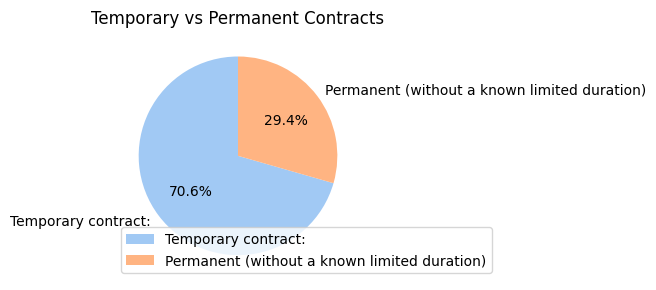

In [69]:

plt.figure(figsize=(6, 6))
plt.pie(
    contract_counts,
    labels=contract_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')[0:len(contract_counts)]
)
plt.title('Temporary vs Permanent Contracts')
plt.tight_layout()
plt.legend()
plt.show()



#####  The pie chart shows the proportion of workers with temporary and permanent contracts. In this dataset, temporary contracts are much more common than permanent ones. This trend suggests a labor market with high job insecurity, where many workers lack long-term employment stability.Temporary contracts are often associated with informal, seasonal, or short-term jobs, while permanent contracts are typical in formal employment.A high share of temporary contracts may indicate limited access to benefits, social protection, and career advancement.Policymakers may need to address this imbalance to promote decent work and economic security.

#### 39. Most common occupations 


                                          Occupation  Count
0       Agricultural, forestry and fishery labourers   6388
1                                      Sales workers   3199
2  Labourers in mining, construction, manufacturi...   2901
3                               Cleaners and helpers   1666
4                           Personal service workers   1007
5       Market-oriented skilled agricultural workers    973
6                             Teaching professionals    796
7  Building and related trades workers, excluding...    778
8  Food processing, wood working, garment and oth...    677
9                 Drivers and mobile plant operators    667


C:\Users\user\AppData\Local\Temp\ipykernel_33396\1591051862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_occupation_counts, x='Count', y='Occupation', palette='Blues_r')


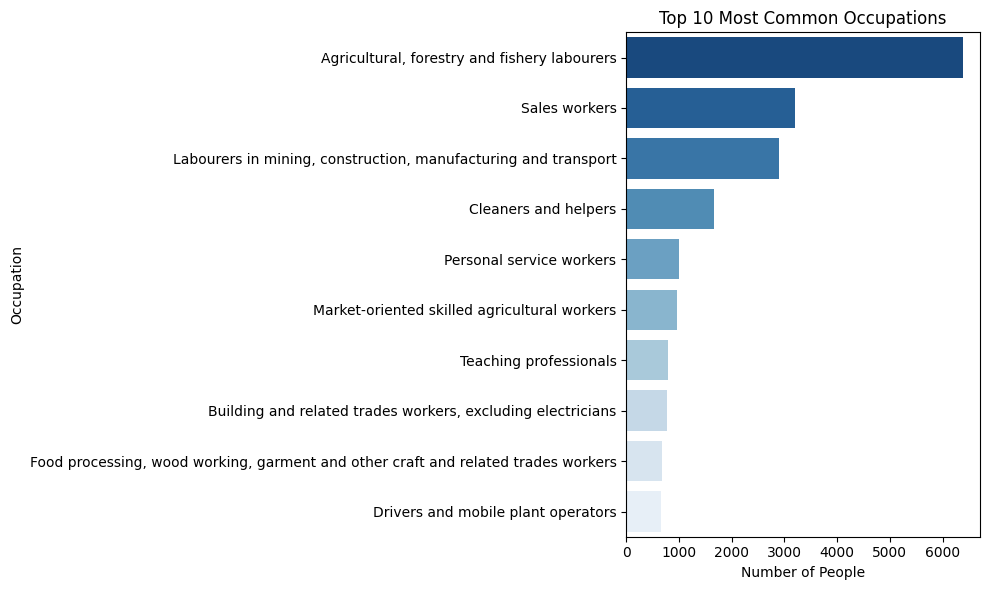

In [68]:

top_occupation_counts = RLF2023_sub['Occupation'].value_counts().nlargest(10).reset_index()
top_occupation_counts.columns = ['Occupation', 'Count']
print(top_occupation_counts)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_occupation_counts, x='Count', y='Occupation', palette='Blues_r')
plt.title('Top 10 Most Common Occupations')
plt.xlabel('Number of People')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()



##### The bar chart of the top 10 most common occupations shows that "Agricultural, forestry and fishery labourers" are the largest group, reflecting the importance of agriculture in the local economy. "Sales workers" and "Labourers in mining, construction, manufacturing and transport" also have high counts, indicating significant employment in trade and manual labor sectors. Occupations like "Cleaners and helpers," "Personal service workers," and "Teaching professionals" highlight the prevalence of service and education roles. The dominance of these occupations suggests that the labor market is heavily concentrated in agriculture, trade, and basic services, with fewer people in specialized or managerial positions. This pattern is typical in developing economies, where informal and low-skilled jobs are more common than formal or highly skilled roles.

---
### The summary statistics and visualizations reveal several key trends in the labor force data:

- **Employment Rate by Gender:** Males have a higher employment rate than females, indicating gender disparities in labor force participation.
- **Unemployment Rate by Region:** Western Province and Kigali city show the highest unemployment rates, likely due to urban migration and job competition.
- **Income by Education Level:** Higher education levels (University, Upper secondary) are associated with higher average monthly incomes, highlighting the economic value of education.
- **Labor Force Participation by Age Group:** Participation peaks in the 25-54 age range and drops for younger and older groups, reflecting typical working-age patterns.
- **Sectoral Employment:** The services sector employs the most people, followed by agriculture and industry.
- **Gender Distribution in Sectors:** Some sectors (e.g., services) have a more balanced gender distribution, while others (e.g., agriculture) are male-dominated.
- **Working Hours:** Men work slightly more hours on average than women; certain occupations have longer average working hours.
- **Income Inequality by Gender:** Males earn higher mean incomes and have greater income variability compared to females.
- **Unemployment by Education:** Unemployment is more prevalent among those with lower education levels, but higher education can also mean longer unemployment spells.
- **Part-Time Work:** Women are more likely to work part-time than men.
- **Dual Job Holding:** Most dual job holders have two jobs; multiple job holding is less common.
- **Income vs. Hours Worked:** There is a positive relationship between hours worked and income, but other factors also influence earnings.
- **Employment by Household Size:** Larger households have more members out of the labor force, reflecting more dependents.
- **Working Parents:** Fathers have higher employment rates than mothers, who are more likely to be out of the labor force.
- **Retirement Age:** Most retire between 60 and 70, with few working beyond 70.
- **Self-Employment:** Informal employment and self-employment are common, especially in developing economies.
- **Disability and Employment:** People with disabilities are less likely to be employed and more likely to be out of the labor force.
- **Access to Benefits:** Formal sectors offer more benefits; informal sectors lag behind.
- **Hourly Wage by Occupation:** Specialized occupations have higher and less variable hourly wages; informal jobs show more wage inequality.
- **Effect of Education:** Higher education increases the likelihood of employment and reduces the risk of being out of the labor force.
- **Contract Type:** Temporary contracts are more common than permanent ones, indicating job insecurity.


---
## *END OF PROJECTS*